In [1]:
%matplotlib inline

In [2]:
#Import your libraries here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import itertools
import os
import sys
from pathlib import Path
from scipy import stats as st
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [3]:
notebook_path = Path(os.getcwd()).resolve()

def get_root(path):
    for parent in [path] + list(path.parents):
        if (parent / "static_data").exists():
            return parent
    return path

PROJECT_ROOT = get_root(notebook_path)
DATA_DIR = PROJECT_ROOT / "static_data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")

Project Root: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project
Data Source:  D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\static_data


In [4]:
import importlib

BASE_URL = "https://storage.googleapis.com/softuni_data_science_final_project_kamend1/static_data/"

from src.data_pipeline_utils import data_fetching_handling as data_pipe
import src.plotting_utils.plotting_utils as plot_utils
import src.signal_testing_utils.signal_testing_utils as sig_utils
importlib.reload(plot_utils)
importlib.reload(data_pipe)
importlib.reload(sig_utils)

<module 'src.signal_testing_utils.signal_testing_utils' from 'D:\\Users\\kamen.dimitrov\\Desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Data_Science\\08_final_project\\src\\signal_testing_utils\\signal_testing_utils.py'>

#### Introduction

With this notebook I will investigate whether some of the most commonly used technical indicators contain statistically significant predictive information about future stock returns.

As I briefly discussed in notebook 1_1, the analysis is motivated by my personal curiosity and is at the core of the central question in this project:

> Do widely used technical signals (such as RSI, MACD, volatility, and moving-average distance) provide measurable and statistically robust forecasting power, or are their apparent effects largely driven by noise?

To address this, the notebook will follow a structured, data-driven approach:

1. **Data Construction**  
   Historical price data is collected for a diversified set of equities using `yfinance`. From these prices, daily returns and log-returns are computed.

2. **Indicator Engineering**  
   Four technical indicators are constructed:
   - Relative Strength Index (RSI)
   - MACD Histogram
   - Rolling Volatility
   - Distance from Moving Average  

   These represent different conceptual “pillars” of technical analysis: momentum, trend, risk, and mean reversion.

3. **Hypothesis Testing Framework**  
   The predictive power of these indicators is evaluated using multiple statistical methods:
   - Correlation analysis  
   - Parametric tests (t-tests, regression models)  
   - Categorical tests (ANOVA, Chi-squared)  

   All tests are conducted at a strict significance level of **$\alpha = 0.01$**.

4. **Signal Transformation**  
   Continuous indicators are converted into categorical trading signals (Buy / Hold / Sell), allowing for direct evaluation of their practical usefulness.

5. **Extension Across Time Horizons**  
   The analysis is extended beyond the next-day return (T+1) to multi-day horizons (T+2, T+3, T+5) to test whether predictive effects are delayed.

6. **Normalization and Robustness**  
   Returns are normalized per ticker to control for heteroscedasticity and cross-sectional volatility differences, ensuring that results are not biased toward more volatile assets.


##### Objective

The primary objective is to determine:

- Whether technical indicators provide **statistically significant predictive signals**
- Whether predictive power is **immediate or delayed**
- Whether signals operate **independently, additively, or conditionally (through interactions)**
- Whether a **combined trading signal** can be constructed based on empirical evidence


##### Scope and Limitations

This notebook focuses exclusively on **price-based technical signals**. It does not incorporate:

- Fundamental data  
- Macroeconomic variables  
- Textual or sentiment-based information (subject to investigation separately in notebook 1_3)

Therefore, the final output of this notebook will be a dataset containing:
- Date and ticker  
- Price information  
- A single combined trading signal per observation  

This dataset is goind to serve as the input for portfolio simulation later in the final notebook 1_4.

#### 1. Preprate the data

In [5]:
tickers = [
    "AAPL", "GOOG", "MSFT", "NVDA",
    "JPM", "BAC", "F", "UPS", "WMT", "TGT",
    "VZ", "T", "FE", "PFE", "JNJ", "DIS",
    "V", "MCD", "NKE", "XOM", "CVX",
    "CAT", "DE", "LMT", "AMD", "INTC", "ORCL", 
    "CRM", "CB", "PG"
]

In [6]:
returns_df =  pd.read_csv(BASE_URL + "stock_returns_static_dataset.csv")
returns_df['Date'] = pd.to_datetime(returns_df['Date'])
returns_df_long = returns_df.melt(id_vars=['Date'], var_name='Ticker', value_name='log_return')
returns_df_long

,Date,Ticker,log_return
0,2016-04-01,AAPL,0.009133
1,2016-04-04,AAPL,0.010221
2,2016-04-05,AAPL,-0.011859
3,2016-04-06,AAPL,0.010418
4,2016-04-07,AAPL,-0.022051
...,...,...,...
75385,2026-03-24,PG,-0.005781
75386,2026-03-25,PG,0.005295
75387,2026-03-26,PG,-0.010477
75388,2026-03-27,PG,0.002034


In [7]:
close_price_df =  pd.read_csv(BASE_URL + "stock_close_prices_static_dataset.csv")
close_price_df['Date'] = pd.to_datetime(returns_df['Date'])
close_price_df_long = close_price_df.melt(id_vars=['Date'], var_name='Ticker', value_name='close_price')
close_price_df_long

,Date,Ticker,close_price
0,2016-04-01,AAPL,24.684103
1,2016-04-04,AAPL,24.910585
2,2016-04-05,AAPL,25.166506
3,2016-04-06,AAPL,24.869822
4,2016-04-07,AAPL,25.130268
...,...,...,...
75415,2026-03-25,PG,143.160004
75416,2026-03-26,PG,143.919998
75417,2026-03-27,PG,142.419998
75418,2026-03-30,PG,142.710007


In [8]:
price_return_df_long = returns_df_long.merge(close_price_df_long, how='left', on=['Date', 'Ticker'])
price_return_df_long = price_return_df_long.sort_values(['Ticker', 'Date'])
price_return_df_long

,Date,Ticker,log_return,close_price
0,2016-04-01,AAPL,0.009133,24.684103
1,2016-04-04,AAPL,0.010221,24.910585
2,2016-04-05,AAPL,-0.011859,25.166506
3,2016-04-06,AAPL,0.010418,24.869822
4,2016-04-07,AAPL,-0.022051,25.130268
...,...,...,...,...
50255,2026-03-24,XOM,0.026034,161.130005
50256,2026-03-25,XOM,-0.012902,165.380005
50257,2026-03-26,XOM,0.013204,163.259995
50258,2026-03-27,XOM,0.033057,165.429993


#### 2. Calculate four of the most prominent technical indicators

In [9]:
price_return_df_long = sig_utils.technical_indicator_engine(price_return_df_long)
price_return_df_long

,Date,Ticker,log_return,close_price,rsi_14,macd_line,macd_signal,macd_hist,volatility_20,ma_50_dist,target_log_return_t1
0,2016-04-01,AAPL,0.009133,24.684103,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010221
1,2016-04-04,AAPL,0.010221,24.910585,0.000000,0.018067,0.003613,0.014454,0.000000,0.000000,-0.011859
2,2016-04-05,AAPL,-0.011859,25.166506,0.000000,0.052431,0.013377,0.039054,0.000000,0.000000,0.010418
3,2016-04-06,AAPL,0.010418,24.869822,0.000000,0.055090,0.021720,0.033371,0.000000,0.000000,-0.022051
4,2016-04-07,AAPL,-0.022051,25.130268,0.000000,0.077322,0.032840,0.044482,0.000000,0.000000,0.001105
...,...,...,...,...,...,...,...,...,...,...,...
75384,2026-03-23,XOM,0.009102,159.669998,61.925600,3.868865,3.650743,0.218122,0.012172,0.104942,0.026034
75385,2026-03-24,XOM,0.026034,161.130005,71.213512,4.034743,3.727543,0.307200,0.012749,0.109054,-0.012902
75386,2026-03-25,XOM,-0.012902,165.380005,82.201977,4.457756,3.873585,0.584170,0.013307,0.131826,0.013204
75387,2026-03-26,XOM,0.013204,163.259995,74.664536,4.569257,4.012720,0.556538,0.013300,0.111225,0.033057


#### 3. Perform correlation analysis on each signal separately

The objective of this analysis is to evaluate whether commonly used technical indicators contain statistically significant predictive information for next-day stock returns.

For each indicator, we test the following null hypothesis:

**H₀ (Null Hypothesis):**  
There is no linear relationship between the value of the technical indicator at time *t* and the log return at time *t+1*.  
In other words, the indicator does not provide predictive information about next-day returns.

**H₁ (Alternative Hypothesis):**  
There exists a statistically significant relationship between the indicator at time *t* and the log return at time *t+1*.

The analysis is conducted using Pearson correlation and associated p-values, with a strict significance threshold of **$\alpha = 0.01$**. This conservative threshold is chosen to reduce the likelihood of false positives given the large number of observations.

In [10]:
target = "target_log_return_t1"
indicators = ['rsi_14', 'macd_hist', 'volatility_20', 'ma_50_dist']
sig_utils.run_individual_hypothesis_tests(price_return_df_long, target, indicators)

Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
rsi_14          |    -0.008726 | 1.6603e-02 | NO
macd_hist       |    -0.002684 | 4.6127e-01 | NO
volatility_20   |     0.016624 | 5.0257e-06 | YES
ma_50_dist      |    -0.006316 | 8.2938e-02 | NO


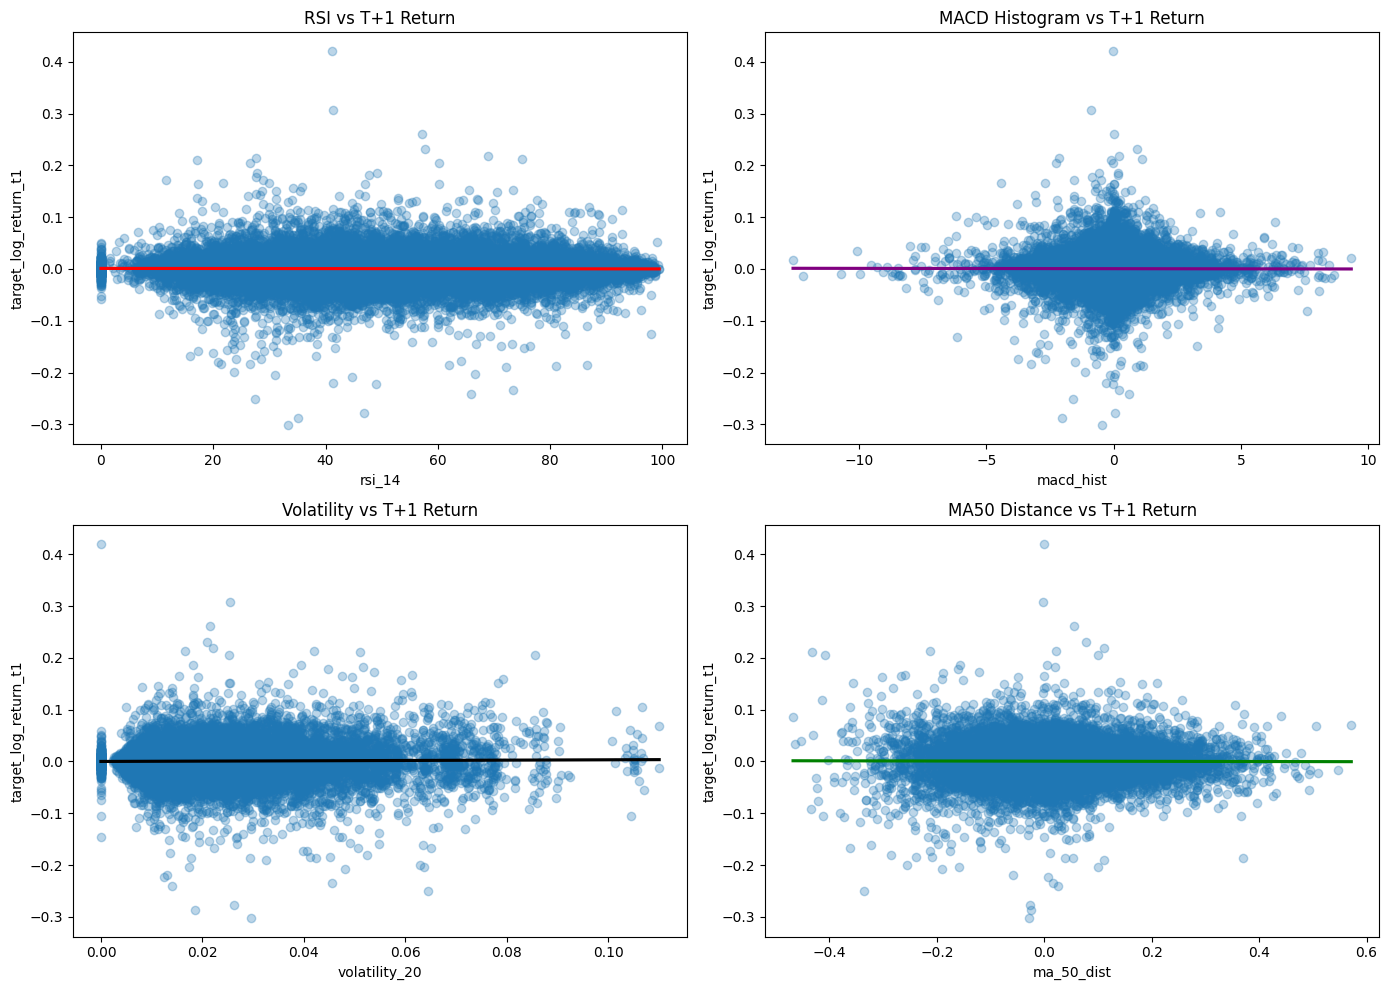

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.regplot(
    x='rsi_14', y='target_log_return_t1',
    data=price_return_df_long,
    ax=axes[0, 0],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
axes[0, 0].set_title('RSI vs T+1 Return')

sns.regplot(
    x='macd_hist', y='target_log_return_t1',
    data=price_return_df_long,
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'purple'}
)
axes[0, 1].set_title('MACD Histogram vs T+1 Return')

sns.regplot(
    x='volatility_20', y='target_log_return_t1',
    data=price_return_df_long,
    ax=axes[1, 0],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'black'}
)
axes[1, 0].set_title('Volatility vs T+1 Return')

sns.regplot(
    x='ma_50_dist', y='target_log_return_t1',
    data=price_return_df_long,
    ax=axes[1, 1],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'green'}
)
axes[1, 1].set_title('MA50 Distance vs T+1 Return')

plt.tight_layout()
plt.show()

**Outcome** - at $\alpha = 0.01$ only the volatility indicator shows statistically significant relationship with the next day returns.

The remaining results indicate that, at the 1% significance level, the majority of technical indicators do not exhibit statistically significant predictive power for next-day returns.

- **RSI (rsi_14):** Not significant (p = 0.0166)  
- **MACD Histogram (macd_hist):** Not significant (p = 0.4613)  
- **MA Distance (ma_50_dist):** Not significant (p = 0.0829)  

However, despite statistical significance, the observed correlation is extremely small (≈ 0.0166), indicating the possibility of negligible economic impact.

At the T+1 horizon, the results provide little evidence that standard technical indicators can meaningfully predict next-day returns.  
Even in the case of volatility, where statistical significance is detected, the effect size is too small to be considered practically useful.

This suggests that, at very short horizons, market behavior is probably dominated by noise, and any potential signal is either extremely weak or quickly absorbed by the market.

#### 4. Perform multivariate analysis on T+1 returns

To complement the univariate analysis, a multivariate regression model is estimated to assess whether a combination of technical indicators jointly explains next-day stock returns.

The model includes:
- RSI (rsi_14)
- MACD Histogram (macd_hist)
- Volatility (volatility_20)
- Moving Average Distance (ma_50_dist)

Additionally, interaction terms are introduced to capture potential nonlinear effects and regime dependencies between indicators.

The null hypothesis is defined as:

**H₀ (Null Hypothesis):**  
None of the included technical indicators, either individually or through their interactions, have explanatory power for next-day log returns.  
Formally, all slope coefficients are equal to zero.

**H₁ (Alternative Hypothesis):**  
At least one indicator or interaction term has statistically significant explanatory power for next-day returns.

The model is estimated using Ordinary Least Squares (OLS), with statistical significance evaluated at a strict threshold of **$\alpha = 0.01$**.

In [12]:
target = "target_log_return_t1"
multivariate_model = sig_utils.run_multivariate_test(price_return_df_long, target)
multivariate_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     target_log_return_t1   R-squared:                       0.000
Model:                              OLS   Adj. R-squared:                  0.000
Method:                   Least Squares   F-statistic:                     3.897
Date:                  Wed, 15 Apr 2026   Prob (F-statistic):           5.80e-05
Time:                          07:49:45   Log-Likelihood:             1.9094e+05
No. Observations:                 75360   AIC:                        -3.819e+05
Df Residuals:                     75350   BIC:                        -3.818e+05
Df Model:                             9                                         
Covariance Type:              nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0006      0.001      1.204      0.229      -0.000       0.002
rsi_14        -1.086e-05   9.63e-06     -1.128      0.259   -2.97e-05    8.02e-06
macd_hist         0.0003      0.000      1.092      0.275      -0.000       0.001
volatility_20     0.0516      0.031      1.648      0.099      -0.010       0.113
ma_50_dist        0.0087      0.004      2.105      0.035       0.001       0.017
RSI_x_Vol        -0.0004      0.001     -0.621      0.535      -0.002       0.001
MACD_x_Vol        0.0019      0.006      0.294      0.769      -0.011       0.014
RSI_x_MACD    -5.257e-06   4.18e-06     -1.258      0.208   -1.34e-05    2.93e-06
RSI_x_MA      -6.606e-05   5.69e-05     -1.160      0.246      -0.000    4.55e-05
Vol_x_MA         -0.1201      0.073     -1.654      0.098      -0.262       0.022
==============================================================================
Omnibus:                    18070.327   Durbin-Watson:                   2.110
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1114602.904
Skew:                          -0.135   Prob(JB):                         0.00
Kurtosis:                      21.839   Cond. No.                     6.42e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.42e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Outcome** - None of the selected indicators have statistically significant predictive power to the stock return at T+1. This holds true in both of the cases analyzed - when the signals are tested separately and together. As a result, the multivariate regression results reveal a pattern: while statistical significance may appear at the model level for volatility, the overall explanatory and economic value of the model is negligible for next-day returns.

**Interpretation of results**

- The model is **statistically significant overall** (Prob(F-statistic) ≈ 5.80e-05), suggesting that at least one variable contributes marginally to explaining returns.
- However, the **R² is effectively zero**, indicating that the model explains virtually none of the variation in next-day returns.
- At the strict significance level of α = 0.01:
  - **No individual coefficient is statistically significant**
  - Even variables with lower p-values (e.g., ma_50_dist, volatility_20) do not meet the required threshold

**Additional observations provided by the model**

- Coefficient magnitudes are extremely small, implying **no meaningful economic impact**
- The **high condition number (6.42e+04)** suggests potential multicollinearity or numerical instability
- Residual diagnostics (high kurtosis and significant Jarque-Bera test) indicate that the error distribution deviates strongly from normality

**Conclusion**

Despite statistical significance at the aggregate level, the model lacks both explanatory and practical predictive power.

This reinforces the earlier findings that at the T+1 horizon, stock returns are largely dominated by noise, and even when combining multiple technical indicators and interaction terms, no economically meaningful predictive structure emerges.

The apparent statistical significance is primarily driven by the large sample size rather than true underlying signal.

#### 5. Creating signals and testing them for significance on T+1 returns

To convert continuous technical indicators into actionable trading signals, I will apply three distinct mathematical approaches, depending on the nature of each indicator.

**1. Fixed Thresholds (The "Extreme" Method)**

Used for indicators with a bounded scale, such as RSI (0–100).  
The approach focuses only on extreme values, ignoring the “middle noise”. I would like to test the typical thresholds established by numerous examples RSI below 30 and RSI above 70 as follows:.

- **+1 (Buy):** RSI < 30 (Oversold)  
- **0 (Neutral):** RSI between 30 and 70  
- **-1 (Sell):** RSI > 70 (Overbought)

**Possible rationale:**  
This method addresses non-linearity observed in regression analysis by isolating only extreme conditions. It effectively tells the model to focus on situations where the indicator signals strong market imbalance.

**2. Crossover Logic (The "Momentum Flip" Method)**

Used for oscillating indicators such as the MACD Histogram, where direction is more informative than magnitude as follows.

- **+1 (Buy):** Histogram > 0 and previous value ≤ 0 (Bullish crossover)  
- **-1 (Sell):** Histogram < 0 and previous value ≥ 0 (Bearish crossover)  
- **0 (Neutral):** All other cases

**Possible rationale:**  
This method captures inflection points in momentum. Instead of relying on small numerical differences, it translates continuous signals into discrete “trend change” events.

**3. Statistical Quantiles (The "Relative" Method)**

Used for unbounded indicators such as volatility or moving average distance, where absolute values are not directly comparable across assets.

- Compute the 25th and 75th percentiles of the indicator for each ticker  
- **+1 (Buy):** Value in the bottom 25% (relative stability or undervaluation)  
- **-1 (Sell):** Value in the top 25% (relative stress or overextension)  
- **0 (Neutral):** Middle 50% range

**Possible rationale:**  
This method normalizes signals across different assets. It ensures that indicator values are interpreted relative to each asset’s own historical distribution, making signals comparable across stocks with different volatility and price dynamics.

In [13]:
final_signal_df = sig_utils.create_categorical_signals(price_return_df_long)
final_signal_df

,Date,Ticker,log_return,close_price,rsi_14,macd_line,macd_signal,macd_hist,volatility_20,ma_50_dist,target_log_return_t1,sig_rsi,sig_macd,sig_vol,sig_ma_dist
0,2016-04-01,AAPL,0.009133,24.684103,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010221,1,0,1,0
1,2016-04-04,AAPL,0.010221,24.910585,0.000000,0.018067,0.003613,0.014454,0.000000,0.000000,-0.011859,1,1,1,0
2,2016-04-05,AAPL,-0.011859,25.166506,0.000000,0.052431,0.013377,0.039054,0.000000,0.000000,0.010418,1,0,1,0
3,2016-04-06,AAPL,0.010418,24.869822,0.000000,0.055090,0.021720,0.033371,0.000000,0.000000,-0.022051,1,0,1,0
4,2016-04-07,AAPL,-0.022051,25.130268,0.000000,0.077322,0.032840,0.044482,0.000000,0.000000,0.001105,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75384,2026-03-23,XOM,0.009102,159.669998,61.925600,3.868865,3.650743,0.218122,0.012172,0.104942,0.026034,0,0,0,0
75385,2026-03-24,XOM,0.026034,161.130005,71.213512,4.034743,3.727543,0.307200,0.012749,0.109054,-0.012902,-1,0,0,0
75386,2026-03-25,XOM,-0.012902,165.380005,82.201977,4.457756,3.873585,0.584170,0.013307,0.131826,0.013204,-1,0,0,0
75387,2026-03-26,XOM,0.013204,163.259995,74.664536,4.569257,4.012720,0.556538,0.013300,0.111225,0.033057,-1,0,0,0


**Signal Performance Testing**

After transforming continuous indicators into categorical trading signals, the next step is to evaluate whether these signals translate into meaningful differences in future returns.

For each signal, we test the following null hypothesis:

**H₀ (Null Hypothesis):**  
The mean next-day return following a Buy signal (+1) is equal to the mean return during Neutral periods (0).  
Formally:  
$$E[r_{t+1} \mid \text{Buy}] = E[r_{t+1} \mid \text{Neutral}]$$

**H₁ (Alternative Hypothesis):**  
The mean return following a Buy signal differs from the mean return during Neutral periods.

This is evaluated using a two-sample t-test for each signal.  
Statistical significance is assessed at a strict level of **$\alpha = 0.01$**.

The goal is to determine whether discretizing indicators into trading signals results in economically and statistically meaningful differences in returns.

In [14]:
target = 'target_log_return_t1'
signal_alpha = sig_utils.verify_signal_performance(final_signal_df, target)
signal_alpha

,Signal,Buy_Mean_Return,Neutral_Mean_Return,T_Statistic,P_Value,Significant_01
0,sig_rsi,0.000607,0.000606,0.002122,0.998307,False
1,sig_macd,0.001089,0.000521,1.587151,0.112483,False
2,sig_vol,0.000422,0.000454,-0.216677,0.828461,False
3,sig_ma_dist,0.000561,0.000570,-0.025859,0.979370,False


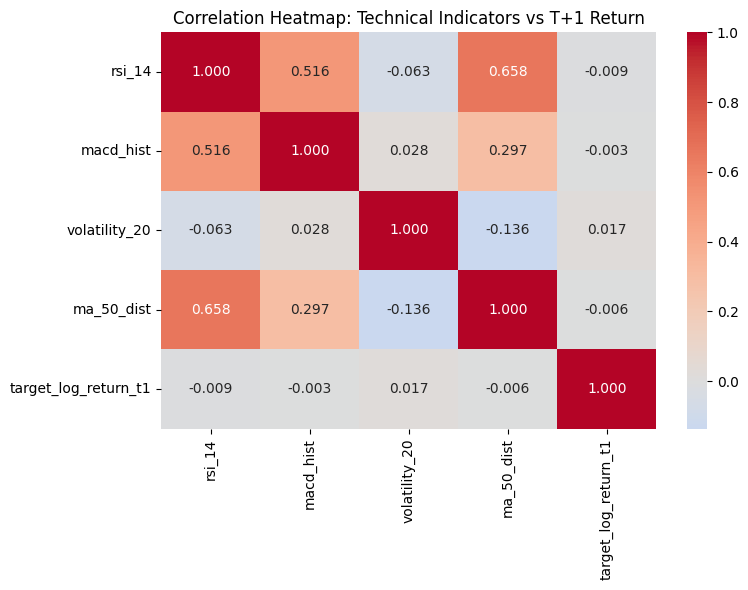

In [36]:
plot_cols = [
    'rsi_14', 'macd_hist', 'volatility_20', 'ma_50_dist',
    'target_log_return_t1'
]

heatmap_df = price_return_df_long[plot_cols].dropna().copy()

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.3f'
)
plt.title('Correlation Heatmap: Technical Indicators vs T+1 Return')
plt.tight_layout()
plt.show()

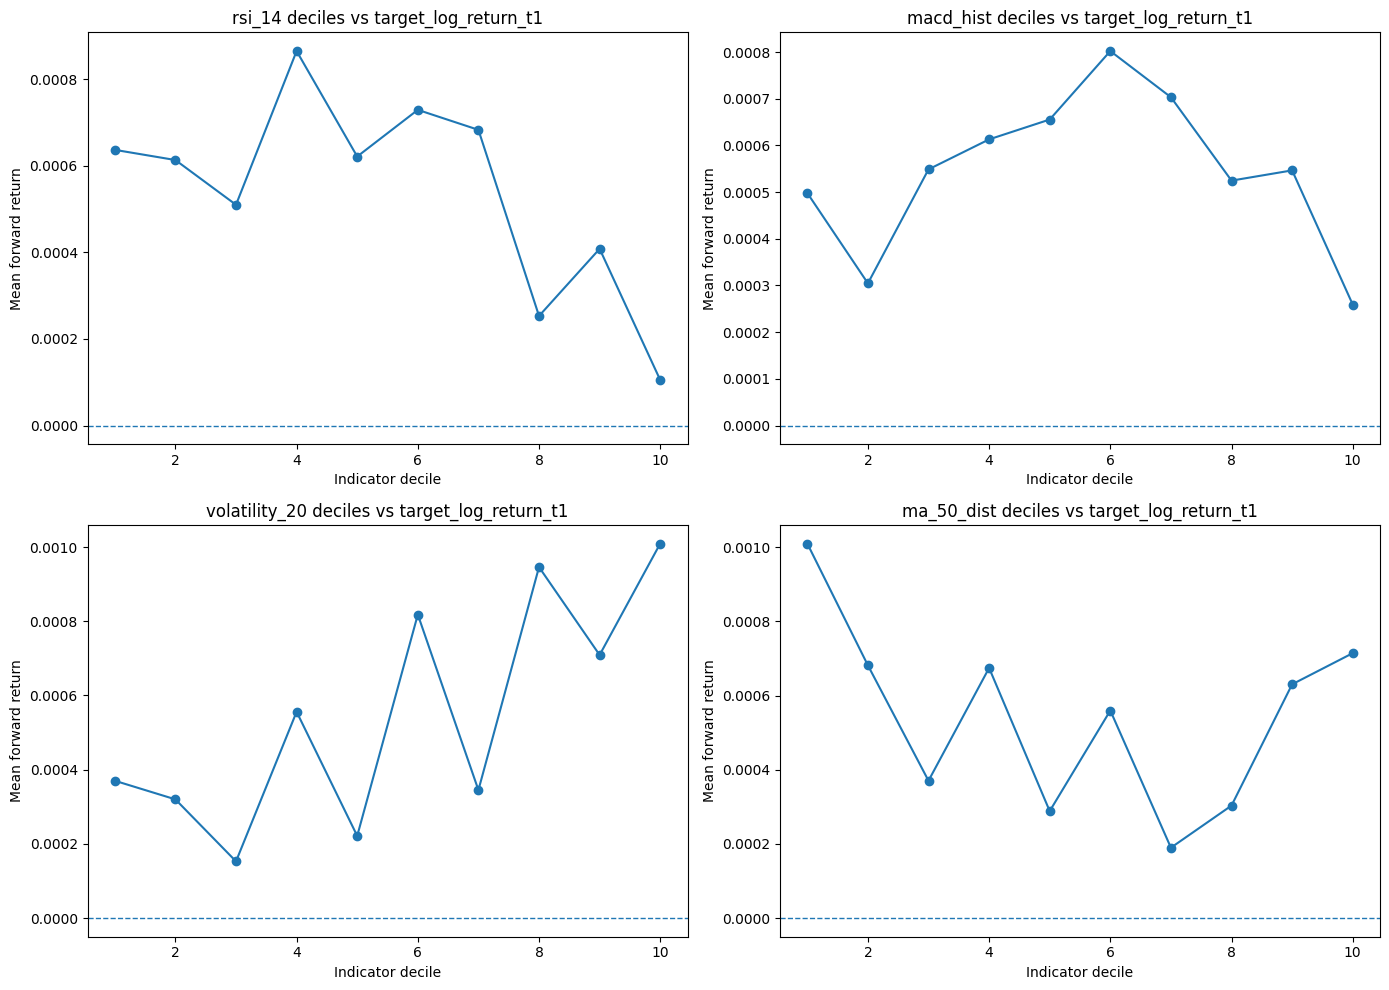

In [37]:
def plot_indicator_deciles(df, indicator, target, ax, n_bins=10):
    temp = df[[indicator, target]].dropna().copy()
    temp = temp[temp[indicator] != 0]  # remove warm-up zeros where relevant

    temp['bin'] = pd.qcut(temp[indicator], q=n_bins, duplicates='drop')
    grouped = temp.groupby('bin', observed=False)[target].mean()

    ax.plot(range(1, len(grouped) + 1), grouped.values, marker='o')
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title(f'{indicator} deciles vs {target}')
    ax.set_xlabel('Indicator decile')
    ax.set_ylabel('Mean forward return')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

indicators = ['rsi_14', 'macd_hist', 'volatility_20', 'ma_50_dist']
for ax, indicator in zip(axes.flatten(), indicators):
    plot_indicator_deciles(price_return_df_long, indicator, 'target_log_return_t1', ax)

plt.tight_layout()
plt.show()

**Outcome** - The results show that none of the constructed signals exhibit statistically significant differences in returns at the 1% significance level.

- **RSI Signal (sig_rsi):**  
  Buy and Neutral mean returns are virtually identical (0.000607 vs 0.000606), with a p-value ≈ 0.998 → no effect.

- **MACD Signal (sig_macd):**  
  Buy returns appear higher than Neutral (0.001089 vs 0.000521), but the result is not statistically significant (p ≈ 0.112).

- **Volatility Signal (sig_vol):**  
  No meaningful difference between Buy and Neutral states (p ≈ 0.828).

- **MA Distance Signal (sig_ma_dist):**  
  No observable difference in returns (p ≈ 0.979).

**Conclusion**

Across all indicators, the null hypothesis cannot be rejected.

This indicates that converting technical indicators into categorical Buy signals does not produce statistically significant improvements in predicting next-day returns.

The results suggest that:
- Any apparent differences in mean returns are likely due to random variation
- Discretization alone does not create predictive power
- At the T+1 horizon, signals derived from these indicators do not provide economically meaningful trading information

**ANOVA Testing Framework for Categorical Signals**

To further evaluate the predictive power of the constructed categorical signals, I will also apply a one-way ANOVA test.

Unlike the previous t-test, which compares Buy vs Neutral states, ANOVA allows us to test whether **any difference exists across all three signal states**:

- **-1 (Sell)**
- **0 (Neutral)**
- **+1 (Buy)**

The null hypothesis is defined as:

**H₀ (Null Hypothesis):**  
The mean next-day return is equal across all signal categories.  
$$E[r_{t+1} \mid \text{Sell}] = E[r_{t+1} \mid \text{Neutral}] = E[r_{t+1} \mid \text{Buy}]$$

**H₁ (Alternative Hypothesis):**  
At least one group mean differs from the others.

Statistical significance is evaluated at a strict threshold of **$\alpha = 0.01$**.

This test assesses whether the signal categories meaningfully partition return outcomes.

In [15]:
target = "target_log_return_t1"
indicators = ['sig_rsi', 'sig_macd', 'sig_vol', 'sig_ma_dist']
anova_df = sig_utils.run_multivariate_anova(final_signal_df, target, indicators)
anova_df

,Indicator,F_Statistic,P_Value,Reject_H0_01
0,sig_rsi,1.799542,0.165382,False
1,sig_macd,1.265993,0.281965,False
2,sig_vol,3.136641,0.043434,False
3,sig_ma_dist,0.664606,0.514479,False


**Outcome** - The ANOVA results indicate that none of the categorical signals produce statistically significant differences in next-day returns at the 1% significance level.

- **RSI Signal (sig_rsi):**  
  Not significant (p ≈ 0.165)

- **MACD Signal (sig_macd):**  
  Not significant (p ≈ 0.282)

- **Volatility Signal (sig_vol):**  
  Shows the lowest p-value (p ≈ 0.043), but still does not meet the α = 0.01 threshold

- **MA Distance Signal (sig_ma_dist):**  
  Not significant (p ≈ 0.514)

Across all indicators, the null hypothesis cannot be rejected. Even when considering all three signal states simultaneously, there is no statistically significant evidence that the signals partition returns into distinct groups. Although the volatility signal exhibits a relatively lower p-value, this result is insufficient under the stricter significance criterion and may reflect weak or unstable effects.

**Conclusion**

The ANOVA results reinforce previous findings:

- Categorical signal construction does not produce meaningful differentiation in next-day returns  
- No indicator provides statistically robust predictive power at the T+1 horizon  
- Any observed variation in returns across signal states is consistent with random noise

This further supports the conclusion that short-term market movements are largely unpredictable using these technical signals.

**Chi-Squared Test for Directional Predictive Power**

In addition to analyzing return magnitudes, we test whether the categorical signals provide information about the **direction** of future returns.

The outcome variable is defined as:
- **1 (Win):** next-day return > 0  
- **0 (Loss):** next-day return ≤ 0  

For each signal, a contingency table is constructed between signal categories (-1, 0, +1) and outcome (win/loss).

The null hypothesis is defined as:

**H₀ (Null Hypothesis):**  
The signal is independent of the direction of future returns, and the probability of a positive return is the same regardless of the signal state.

**H₁ (Alternative Hypothesis):**  
The signal and return direction are not independent.

The Chi-squared test of independence is used, with statistical significance evaluated at **$\alpha = 0.01$**.

In [16]:
target = "target_log_return_t1"
chi2_df = sig_utils.run_signal_chi2_aligned(final_signal_df, target)
chi2_df

,Indicator,Chi2_Stat,P_Value,Significant_01,Observations
0,sig_rsi,2.503683,0.113580,False,21109
1,sig_macd,0.737948,0.390319,False,6015
2,sig_vol,0.440096,0.507076,False,37472
3,sig_ma_dist,0.432718,0.510658,False,10220


**Outcome** - The results show that none of the categorical signals exhibit a statistically significant relationship with the direction of next-day returns.

- **RSI Signal (sig_rsi):**  
  Not significant (p ≈ 0.114)

- **MACD Signal (sig_macd):**  
  Not significant (p ≈ 0.390)

- **Volatility Signal (sig_vol):**  
  Not significant (p ≈ 0.507)

- **MA Distance Signal (sig_ma_dist):**  
  Not significant (p ≈ 0.511)

Across all indicators, the null hypothesis of independence cannot be rejected. This indicates that:
- The signals do not meaningfully influence the probability of a positive vs negative return  
- There is no evidence that signal states are associated with directional outcomes  
- Technical signals do not provide directional predictive power at the T+1 horizon  
- The probability of a positive return remains effectively unchanged regardless of signal state  
- Any apparent differences in win/loss frequencies are consistent with random variation  

Together with prior tests, this reinforces the conclusion that short-term price movements are largely unpredictable using these indicators.

**Interaction ANOVA: RSI and Volatility**

While previous tests evaluated indicators independently, this analysis examines whether predictive power emerges through **interaction effects** between indicators. Rather than testing all possible combinations, I will focus specifically on the interaction between **RSI and volatility**.

This choice is hypothesis-driven:

- **RSI (Relative Strength Index)** captures momentum extremes (overbought / oversold conditions)
- **Volatility** captures the market regime (stable vs stressed environments)

Prior results showed:
- RSI alone does not exhibit predictive power
- Volatility alone shows weak or borderline effects
- Signals appear to behave differently across time horizons

This is why I would like to test public statements that:
> The effectiveness of momentum signals may depend on the underlying volatility regime.

Therefore, I test whether RSI signals become meaningful **only under specific volatility conditions**:
- **H₀₁:** RSI has no effect on returns  
- **H₀₂:** Volatility has no effect on returns  
- **H₀₃:** There is no interaction effect between RSI and volatility  

The interaction hypothesis specifically tests whether the effect of RSI depends on the volatility regime.

Statistical significance is evaluated at **$\alpha = 0.01$**.

In [17]:
formula = 'target_log_return_t1 ~ C(sig_rsi) + C(sig_vol) + C(sig_rsi):C(sig_vol)'
model = ols(formula, data=final_signal_df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)

print("\n--- Interaction ANOVA (RSI x Volatility) ---")
print(aov_table)


--- Interaction ANOVA (RSI x Volatility) ---
                          sum_sq       df         F    PR(>F)
C(sig_rsi)              0.001155      2.0  1.565571  0.208976
C(sig_vol)              0.002141      2.0  2.902832  0.054874
C(sig_rsi):C(sig_vol)   0.005774      4.0  3.913722  0.003521
Residual               27.792171  75351.0       NaN       NaN


**Outcome** - The ANOVA results reveal a key finding: while individual indicators do not show statistically significant effects, their interaction does.

- **RSI (main effect):**  
  Not significant (p ≈ 0.209)

- **Volatility (main effect):**  
  Not significant at α = 0.01 (p ≈ 0.055)

- **RSI × Volatility (interaction effect):**  
  **Statistically significant (p ≈ 0.0035)**

The results indicate that:
- Neither RSI nor volatility independently explains next-day returns  
- However, the **effect of RSI depends on the volatility regime**

This suggests a **conditional relationship**:
- Momentum signals (RSI) may only become informative under certain levels of market uncertainty  
- Predictive structure is not additive, but **state-dependent**

Only a limited number of interaction terms are tested, focusing on economically justified relationships.  
Testing all possible combinations would introduce:
- multiple testing bias  
- increased risk of false positives  
- reduced statistical power due to sample fragmentation  

By focusing on RSI × Volatility, the analysis remains **theory-driven and statistically disciplined**. While standalone technical signals fail to provide predictive power at the T+1 horizon, a statistically significant interaction between RSI and volatility is detected. This represents evidence of **nonlinear structure in market behavior**, where signals may only be meaningful within specific regimes.

However, the overall explanatory power remains extremely low, and further validation is required to assess whether this interaction has economic relevance.

**Confluence Signal Testing (Signal Aggregation)**

In addition to evaluating individual indicators, I will test whether combining multiple directional signals improves predictive performance. **I don't consider the volatility signal as a pure directional signal.**

A **confluence score** is constructed as the sum of selected categorical signals:
$$\text{Confluence Score} = \text{sig\_rsi} + \text{sig\_macd} + \text{sig\_ma\_dist}$$

This score captures the degree of agreement between indicators:
- Positive values → multiple bullish signals  
- Negative values → multiple bearish signals  
- Values near zero → lack of agreement  

The underlying hypothesis is that **strong agreement between these three indicators should correspond to stronger predictive signals**. The null hypothesis is defined as:

**H₀ (Null Hypothesis):**  
The confluence score is independent of the direction of next-day returns.

**H₁ (Alternative Hypothesis):**  
The confluence score is associated with the direction of next-day returns.

A Chi-squared test of independence is applied between the confluence score and the binary return outcome (win/loss), using a significance level of **$\alpha = 0.01$**.

In [18]:
target = "target_log_return_t1"
final_signal_df['confluence_score'] = (
    final_signal_df['sig_rsi'] + 
    final_signal_df['sig_macd'] + 
    final_signal_df['sig_ma_dist']
)

final_signal_df['outcome_win'] = (final_signal_df[target] > 0).astype(int)

# Test if High Confluence (score >= 2) has a better Win-Rate than neutral (0)
contingency_conf = pd.crosstab(final_signal_df['confluence_score'], final_signal_df['outcome_win'])
chi2_c, p_c, dof_c, ex_c = st.chi2_contingency(contingency_conf)

print(f"\n--- Confluence Interaction (Chi-Squared) ---")
print(f"P-Value for Confluence Score: {p_c:.4e}")
print(f"Significant at 0.01? {'YES' if p_c < 0.01 else 'NO'}")


--- Confluence Interaction (Chi-Squared) ---
P-Value for Confluence Score: 4.8311e-01
Significant at 0.01? NO


**Outcome** - The results indicate that the confluence score does not exhibit a statistically significant relationship with the direction of next-day returns. The null hypothesis cannot be rejected, indicating that:
- The degree of agreement between signals does not influence the probability of a positive return  
- Combining multiple indicators into an additive score does not improve predictive performance  

This result suggests that:
- Simple signal aggregation (i.e., stacking indicators) does not create meaningful predictive structure  
- Even when multiple indicators align, the resulting signal remains indistinguishable from noise  

**Conclusion**

The confluence approach fails to provide statistically significant predictive power at the T+1 horizon.

This reinforces previous findings that:
- Individual signals lack predictive strength  
- Aggregating signals does not enhance performance  

Taken together, the evidence suggests that predictive relationships, if present, are not additive in nature. Instead, any structure in the data is more likely to be **conditional**, depending on specific interactions between indicators rather than simple agreement.

**Final Summary Outcome of Statistical Test Suite on T+1 Returns**

The results of the statistical testing framework provide a consistent and nuanced picture of the predictive structure of the analyzed technical indicators.

**1. Interaction Effect: RSI × Volatility**

- **P-Value:** 0.0035  
- **Verdict:** Reject the Null Hypothesis (H₀) for the interaction term at α = 0.01  

This is the most important finding of the analysis. While individual indicators fail to exhibit predictive power, a statistically significant interaction between RSI and volatility is detected.

This indicates that:
- The effect of RSI on next-day returns is **not independent**
- Instead, it is **conditional on the volatility regime**

In practical terms:
> A given RSI signal behaves differently depending on whether the market is in a high- or low-volatility state.

This provides evidence of **nonlinear, regime-dependent structure** in the data.

**2. Failure of Confluence (Signal Aggregation)**

- **P-Value:** 0.4831  
- **Verdict:** Fail to Reject the Null Hypothesis  

Combining multiple indicators into a simple additive score does not improve predictive performance.

This implies that:
- Technical indicators are not **cumulative** in nature  
- Agreement between signals does not increase predictive reliability  

In other words:
> Stacking signals does not create a stronger signal.

This directly contrasts with the interaction result, suggesting that predictive structure arises from **conditional relationships**, not simple aggregation.

**3. ANOVA vs. Chi-Squared: Magnitude vs. Direction**

- **ANOVA (Return Magnitude):**  
  - Interaction term significant (p ≈ 0.0035)

- **Chi-Squared (Return Direction):**  
  - No significant results across all signals (p > 0.20)

The results reveal an important distinction:

- Indicators do not reliably predict the **direction** of returns (win/loss)  
- However, they may influence the **magnitude** of returns under certain conditions  

This suggests that:
> Any predictive structure present is related to **return intensity**, not directional accuracy.

**4. Summary of Hypothesis Testing**

| Hypothesis Category              | Status     | Interpretation |
|---------------------------------|------------|----------------|
| Individual Indicators           | Rejected   | No standalone predictive power |
| Signal Aggregation (Confluence) | Rejected   | No additive effect from combining signals |
| Multivariate Model              | Weak       | Statistically significant but negligible explanatory power |
| Interaction Effects             | Supported  | Conditional relationship detected (RSI × Volatility) |

**5. Key Insight: Role of Volatility**

Across multiple tests, volatility emerges as the most structurally relevant variable for next-day returns:

- It shows weak individual effects  
- It appears in the only significant interaction  
- It consistently influences the behavior of other indicators  

This suggests that:
> Volatility acts as a **regime-defining variable**, shaping how other signals behave.

#### 6. Extend the analysis to T + 2, T + 3, and T + 5

I will extend the analysis to multi-day horizons (T+2, T+3, T+5) to evaluate whether predictive structure emerges beyond the immediate next-day return.  
This allows testing whether any detected relationships reflect delayed market adjustment rather than short-term noise.

**Multi-day targets are constructed below as cumulative forward log returns, computed as the sum of daily log returns over the specified horizon (T+2, T+3, T+5).**

In [19]:
price_return_multiday_df = sig_utils.add_multi_day_targets(final_signal_df)
price_return_multiday_df

,Date,Ticker,log_return,close_price,rsi_14,macd_line,macd_signal,macd_hist,volatility_20,ma_50_dist,target_log_return_t1,sig_rsi,sig_macd,sig_vol,sig_ma_dist,confluence_score,outcome_win,target_log_return_t2,target_log_return_t3,target_log_return_t5
0,2016-04-01,AAPL,0.009133,24.684103,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010221,1,0,1,0,1,1,-0.001638,0.008780,-0.012166
1,2016-04-04,AAPL,0.010221,24.910585,0.000000,0.018067,0.003613,0.014454,0.000000,0.000000,-0.011859,1,1,1,0,2,0,-0.001441,-0.023492,-0.019079
2,2016-04-05,AAPL,-0.011859,25.166506,0.000000,0.052431,0.013377,0.039054,0.000000,0.000000,0.010418,1,0,1,0,1,1,-0.011633,-0.010528,0.005721
3,2016-04-06,AAPL,0.010418,24.869822,0.000000,0.055090,0.021720,0.033371,0.000000,0.000000,-0.022051,1,0,1,0,1,0,-0.020946,-0.017638,0.009686
4,2016-04-07,AAPL,-0.022051,25.130268,0.000000,0.077322,0.032840,0.044482,0.000000,0.000000,0.001105,1,0,1,0,1,1,0.004413,0.017354,0.032273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75379,2026-03-16,XOM,0.007085,156.119995,60.823913,3.157060,3.526116,-0.369056,0.015956,0.109174,0.009999,0,0,0,0,0,1,0.002287,0.005898,0.024502
75380,2026-03-17,XOM,0.009999,157.229996,66.352078,3.374751,3.495843,-0.121092,0.015431,0.111110,-0.007712,0,0,0,0,0,0,-0.004101,0.005401,0.040537
75381,2026-03-18,XOM,-0.007712,158.809998,68.932039,3.632889,3.523252,0.109637,0.014347,0.116441,0.003611,0,1,0,0,1,1,0.013112,0.022215,0.035347
75382,2026-03-19,XOM,0.003611,157.589996,67.107758,3.696411,3.557884,0.138527,0.014350,0.102739,0.009502,0,0,0,0,0,1,0.018604,0.044639,0.044941


**Multi-Horizon Correlation Analysis**

Following the lack of predictive power at the T+1 horizon, the analysis is extended to multi-day forward returns (T+2, T+3, T+5). The objective is to evaluate whether technical indicators exhibit **delayed predictive structure**, rather than immediate effects.

For each indicator, the null hypothesis is:
- **H₀ (Null Hypothesis):**  
There is no linear relationship between the indicator at time *t* and cumulative future returns over the specified horizon.
- **H₁ (Alternative Hypothesis):**  

A statistically significant relationship exists between the indicator and future returns. Pearson correlation is used to assess the relationship, with significance evaluated at **$\alpha = 0.01$**.

In [20]:
targets = ["target_log_return_t2", "target_log_return_t3", "target_log_return_t5"]
indicators = ['rsi_14', 'macd_hist', 'volatility_20', 'ma_50_dist']

for target in targets:
    print(f"\nCorrelation Results for {target}:")
    sig_utils.run_individual_hypothesis_tests(price_return_multiday_df, target, indicators)


Correlation Results for target_log_return_t2:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
rsi_14          |    -0.013333 | 2.5566e-04 | YES
macd_hist       |    -0.004103 | 2.6046e-01 | NO
volatility_20   |     0.026546 | 3.3080e-13 | YES
ma_50_dist      |    -0.014846 | 4.6683e-05 | YES

Correlation Results for target_log_return_t3:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
rsi_14          |    -0.016391 | 6.9448e-06 | YES
macd_hist       |    -0.003010 | 4.0909e-01 | NO
volatility_20   |     0.033919 | 1.3461e-20 | YES
ma_50_dist      |    -0.018338 | 4.9210e-07 | YES

Correlation Results for target_log_return_t5:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
rsi_14          |    -0.014360 | 8.2072e-05 | YES
macd_hist       |     0.000609 | 8.6735e-01 | NO
vo

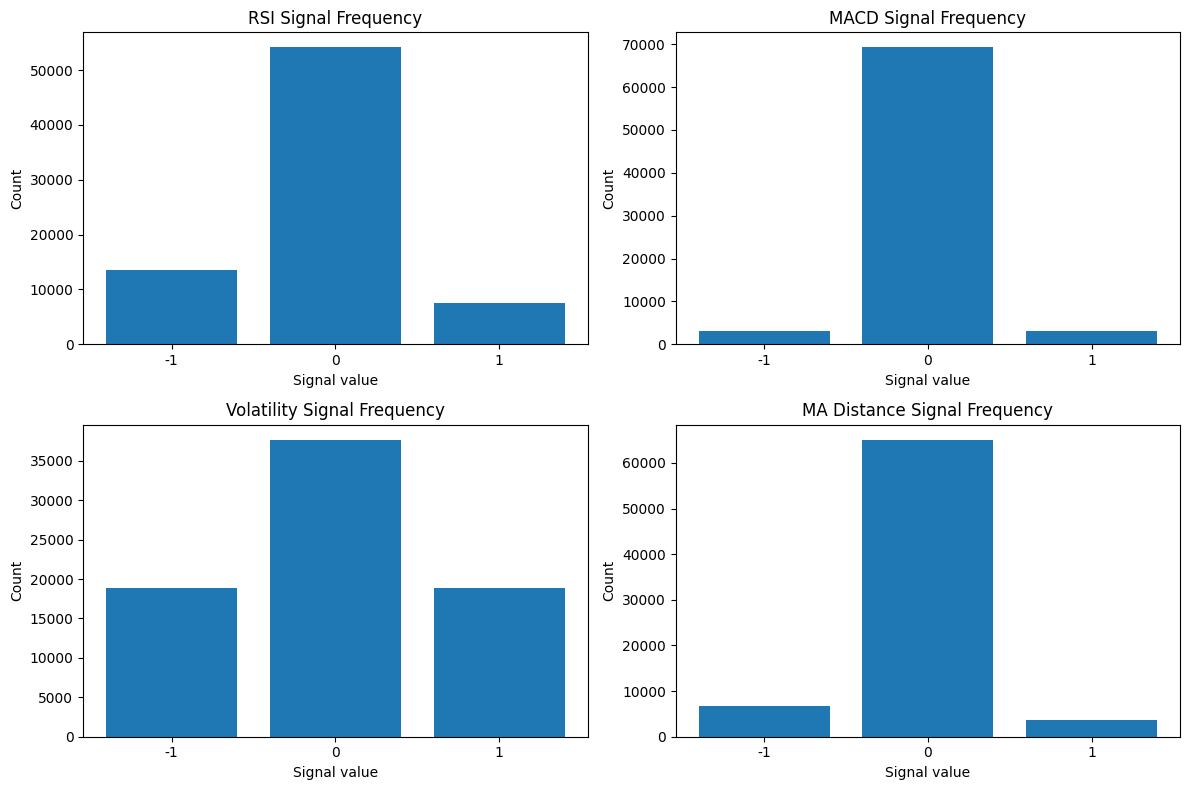

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

signal_cols = ['sig_rsi', 'sig_macd', 'sig_vol', 'sig_ma_dist']
titles = ['RSI Signal Frequency', 'MACD Signal Frequency', 'Volatility Signal Frequency', 'MA Distance Signal Frequency']

for ax, sig_col, title in zip(axes.flatten(), signal_cols, titles):
    counts = final_signal_df[sig_col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(title)
    ax.set_xlabel('Signal value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

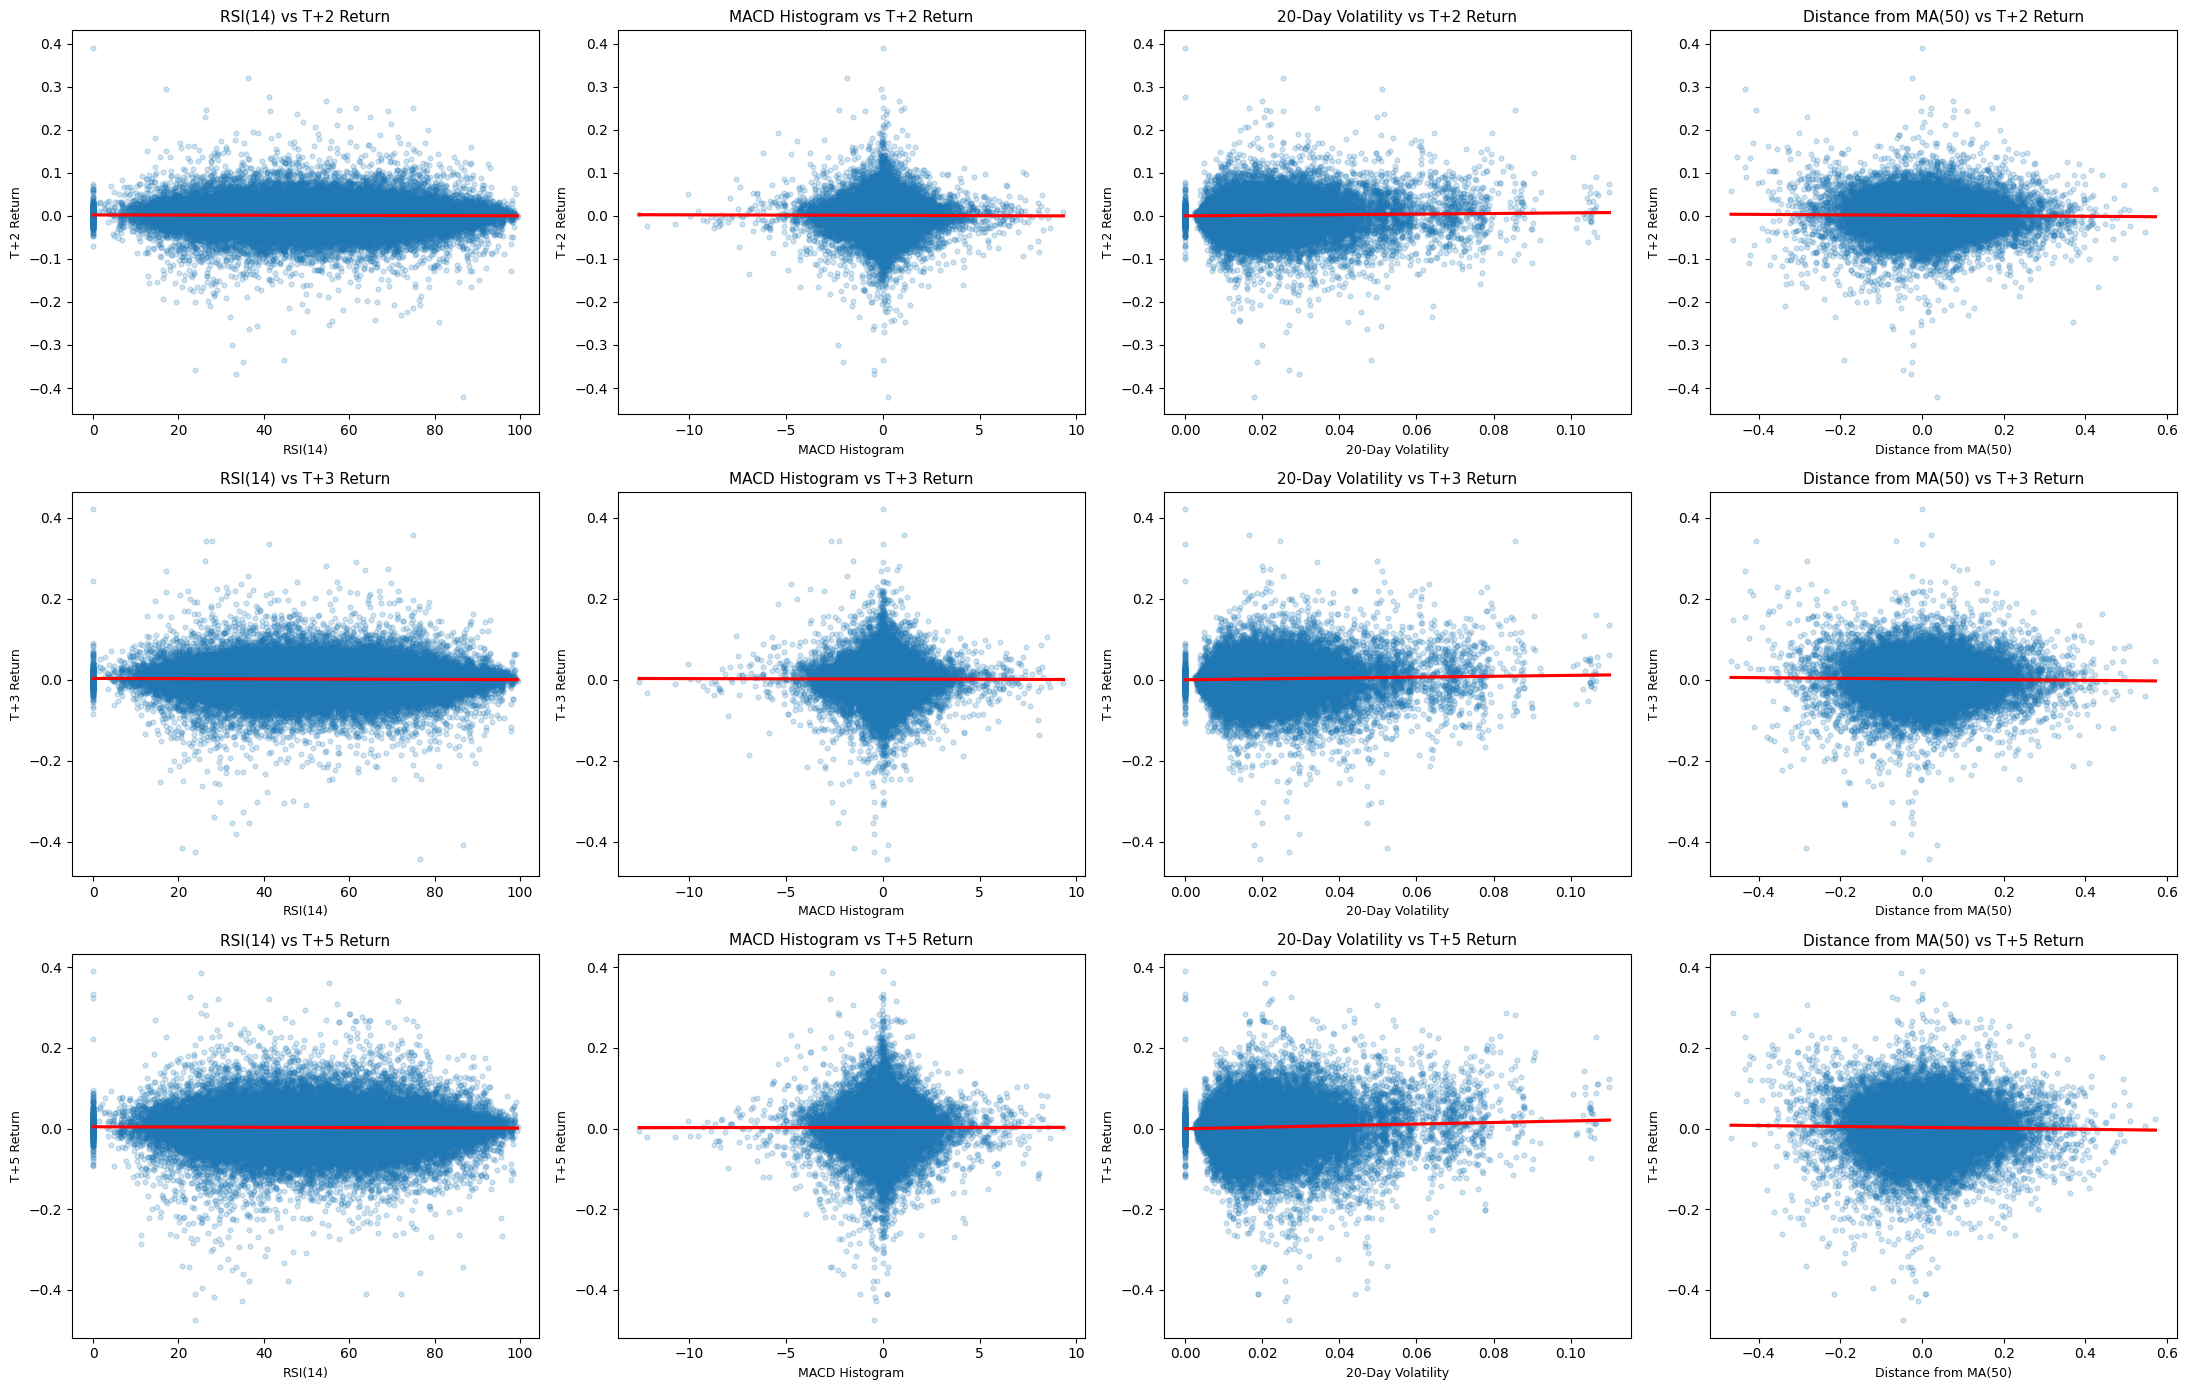

In [21]:
indicator_titles = {
    'rsi_14': 'RSI(14)',
    'macd_hist': 'MACD Histogram',
    'volatility_20': '20-Day Volatility',
    'ma_50_dist': 'Distance from MA(50)'
}

target_titles = {
    'target_log_return_t2': 'T+2 Return',
    'target_log_return_t3': 'T+3 Return',
    'target_log_return_t5': 'T+5 Return'
}

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(22, 14))

for row, target in enumerate(targets):
    for col, indicator in enumerate(indicators):
        ax = axes[row, col]

        sns.regplot(
            x=indicator,
            y=target,
            data=price_return_multiday_df,
            ax=ax,
            scatter_kws={'alpha': 0.2, 's': 12},
            line_kws={'color': 'red'},
            lowess=False  # change to True if you want nonlinear smoothing
        )

        ax.set_title(f"{indicator_titles[indicator]} vs {target_titles[target]}", fontsize=11)
        ax.set_xlabel(indicator_titles[indicator], fontsize=9)
        ax.set_ylabel(target_titles[target], fontsize=9)

plt.tight_layout()
plt.show()

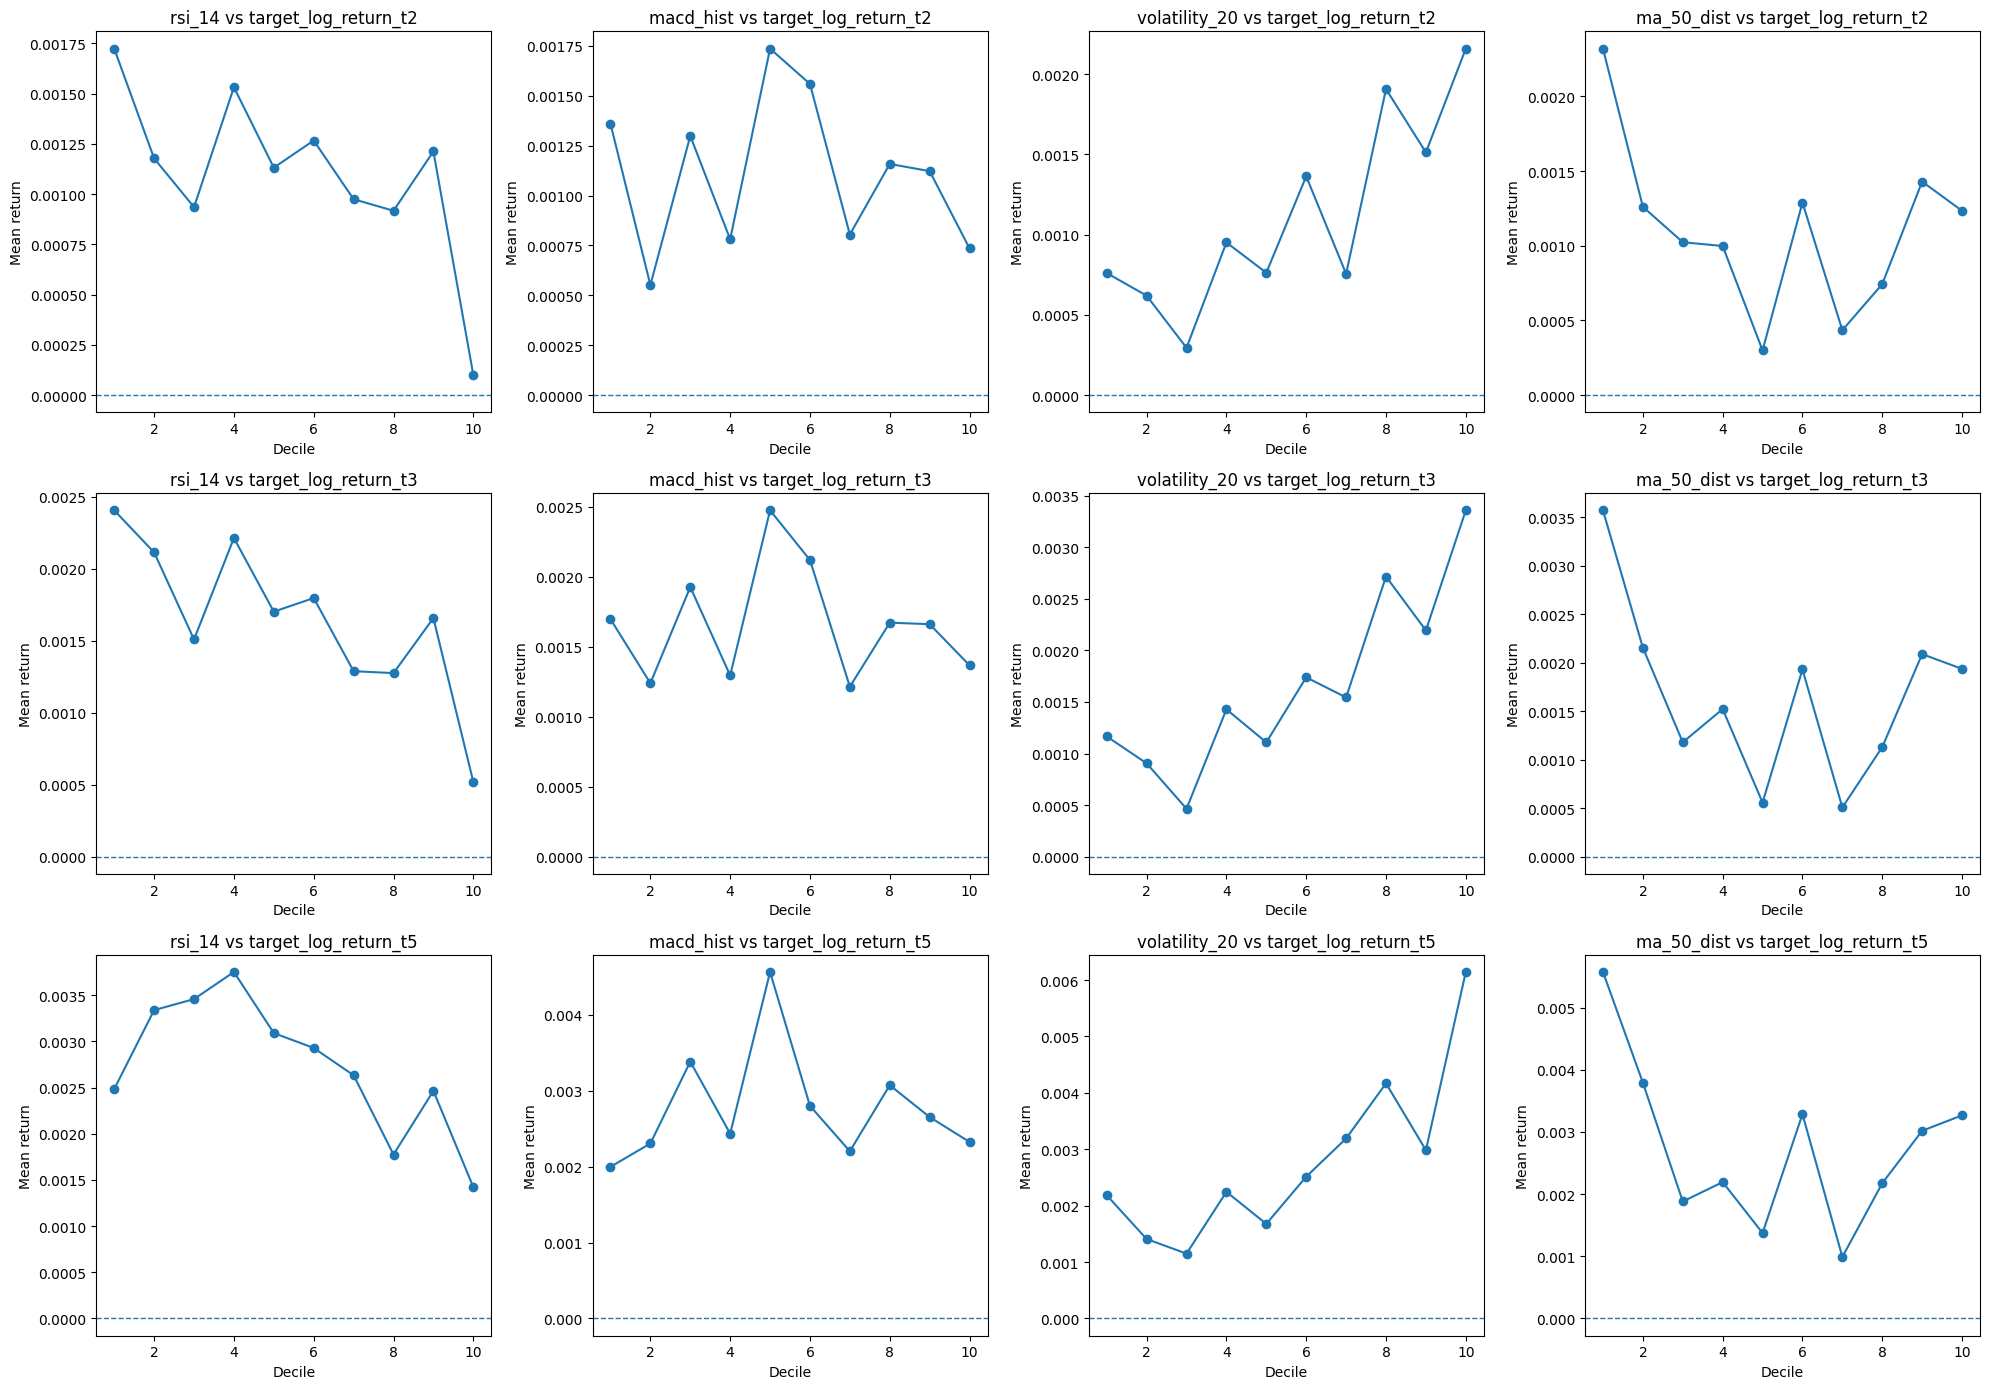

In [40]:
targets = ["target_log_return_t2", "target_log_return_t3", "target_log_return_t5"]
indicators = ['rsi_14', 'macd_hist', 'volatility_20', 'ma_50_dist']

def plot_deciles(df, indicator, target, ax):
    temp = df[[indicator, target]].dropna().copy()
    temp = temp[temp[indicator] != 0]
    temp['bin'] = pd.qcut(temp[indicator], q=10, duplicates='drop')
    grouped = temp.groupby('bin', observed=False)[target].mean()

    ax.plot(range(1, len(grouped) + 1), grouped.values, marker='o')
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title(f'{indicator} vs {target}')
    ax.set_xlabel('Decile')
    ax.set_ylabel('Mean return')

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for row, target in enumerate(targets):
    for col, indicator in enumerate(indicators):
        plot_deciles(price_return_multiday_df, indicator, target, axes[row, col])

plt.tight_layout()
plt.show()

**Outcome** - The results show a consistent shift in behavior compared to the T+1 horizon. Across all extended horizons (T+2, T+3, T+5):

- **RSI (rsi_14):**  
  Statistically significant with negative correlation → suggests mean-reversion behavior advertised by many technical analysts
- **Volatility (volatility_20):**  
  Strongly significant with positive correlation → higher volatility associated with larger future moves
- **MA Distance (ma_50_dist):**  
  Statistically significant with negative correlation → supports mean-reversion dynamics
- **MACD Histogram (macd_hist):**  
  **Not** significant across all horizons
- Predictive relationships **emerge only at longer horizons**, not at T+1  
- Correlation magnitudes remain **very small**, indicating weak economic significance  
- Results are consistent across T+2, T+3, and T+5, suggesting **delayed adjustment rather than immediate reaction**

**Conclusion**

While technical indicators fail to provide predictive power at the next-day level, statistically significant relationships appear over multi-day horizons:
- Market adjustments may occur gradually over several days  
- Indicators capture **weak, delayed structure**, rather than short-term timing signals  

However, the effect sizes are small, and further testing is required to determine whether these relationships translate into economically meaningful trading strategies.

**Multivariate Regression Analysis (Multi-Horizon)**

To evaluate whether predictive structure emerges over longer horizons, a multivariate regression model is estimated for cumulative forward returns at T+2, T+3, and T+5. The model includes the same four indicators as well as interaction terms to capture potential nonlinear and regime-dependent effects.

The null hypothesis is defined as:

**H₀ (Null Hypothesis):**  
None of the indicators or their interactions have explanatory power for future returns at the specified horizon.

**H₁ (Alternative Hypothesis):**  
At least one indicator or interaction term has statistically significant explanatory power.

The model is estimated using Ordinary Least Squares (OLS), with significance evaluated at **$\alpha = 0.01$**.

The objective is to determine whether combining indicators reveals predictive structure that was not observable at the T+1 horizon.

In [22]:
targets = ["target_log_return_t2", "target_log_return_t3", "target_log_return_t5"]

for target in targets:
    multivariate_model = sig_utils.run_multivariate_test(price_return_multiday_df, target)
    print(multivariate_model.summary())

                             OLS Regression Results                             
Dep. Variable:     target_log_return_t2   R-squared:                       0.001
Model:                              OLS   Adj. R-squared:                  0.001
Method:                   Least Squares   F-statistic:                     11.23
Date:                  Wed, 15 Apr 2026   Prob (F-statistic):           9.69e-18
Time:                          07:53:16   Log-Likelihood:             1.6666e+05
No. Observations:                 75210   AIC:                        -3.333e+05
Df Residuals:                     75200   BIC:                        -3.332e+05
Df Model:                             9                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0031  

**Outcome** - The regression results reveal a clear and consistent pattern across increasing time horizons:

- The overall model is **statistically significant at all horizons** (p-values ≪ 0.01)
- **R² increases slightly** from T+2 (~0.001) to T+5 (~0.004), but remains very low
- Several coefficients become statistically significant as the horizon increases, particularly:
  - **RSI (negative effect)** → consistent with mean reversion
  - **Volatility (increasingly negative effect)** → associated with larger future moves
  - **MA Distance (positive effect)** → supporting reversion toward the mean
  - **RSI × Volatility interaction** → strongly significant and increasing with horizon
- Predictive structure becomes **stronger and more consistent at longer horizons**
- The **RSI × Volatility interaction** emerges as a stable and significant relationship across all horizons
- Additional interaction effects (e.g., Volatility × MA) also become highly significant at longer horizons

However:
- The explanatory power remains extremely low (**R² < 0.5%**)
- Coefficient magnitudes are small, indicating the possibility of a limited economic impact

**Conclusion**

The multivariate results confirm that:

- No meaningful predictive structure exists at T+1  
- Weak but statistically significant relationships emerge over multi-day horizons  
- Predictive effects are primarily **conditional and interaction-driven**, rather than additive  

This suggests that market adjustments occur gradually, and that technical indicators capture **delayed, regime-dependent dynamics** rather than immediate price movements.

While statistically detectable, these effects remain small and require further evaluation to determine their practical usefulness in a trading context.

#### 7. Extension: Analysis with Normalized Returns

The preceding results indicate that statistical relationships emerge at multi-day horizons (T+2, T+3, T+5), particularly involving volatility and interaction effects. However, these findings may be influenced by cross-sectional differences in return dispersion across assets.

To address this, the next step is to repeat the analysis using **normalized (z-scored) returns computed within each ticker**. This transformation removes scale effects and volatility heterogeneity, allowing for a more comparable evaluation across securities.

The objective is to assess whether the previously observed relationships persist after controlling for volatility bias, thereby testing the robustness of the findings under a standardized return framework.

In [23]:
targets = ["target_log_return_t1", "target_log_return_t2", "target_log_return_t3", "target_log_return_t5"]
price_return_multiday_df = sig_utils.normalize_targets_per_ticker(price_return_multiday_df, targets)
price_return_multiday_df

,Date,Ticker,log_return,close_price,rsi_14,macd_line,macd_signal,macd_hist,volatility_20,ma_50_dist,...,sig_ma_dist,confluence_score,outcome_win,target_log_return_t2,target_log_return_t3,target_log_return_t5,norm_target_log_return_t1,norm_target_log_return_t2,norm_target_log_return_t3,norm_target_log_return_t5
0,2016-04-01,AAPL,0.009133,24.684103,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,1,1,-0.001638,0.008780,-0.012166,0.510476,-0.138634,0.196168,-0.431312
1,2016-04-04,AAPL,0.010221,24.910585,0.000000,0.018067,0.003613,0.014454,0.000000,0.000000,...,0,2,0,-0.001441,-0.023492,-0.019079,-0.701640,-0.130791,-0.856361,-0.609063
2,2016-04-05,AAPL,-0.011859,25.166506,0.000000,0.052431,0.013377,0.039054,0.000000,0.000000,...,0,1,1,-0.011633,-0.010528,0.005721,0.521279,-0.537002,-0.433550,0.028570
3,2016-04-06,AAPL,0.010418,24.869822,0.000000,0.055090,0.021720,0.033371,0.000000,0.000000,...,0,1,0,-0.020946,-0.017638,0.009686,-1.261150,-0.908167,-0.665442,0.130527
4,2016-04-07,AAPL,-0.022051,25.130268,0.000000,0.077322,0.032840,0.044482,0.000000,0.000000,...,0,1,1,0.004413,0.017354,0.032273,0.010039,0.102517,0.475791,0.711254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75379,2026-03-16,XOM,0.007085,156.119995,60.823913,3.157060,3.526116,-0.369056,0.015956,0.109174,...,0,0,1,0.002287,0.005898,0.024502,0.544064,0.056937,0.151098,0.575392
75380,2026-03-17,XOM,0.009999,157.229996,66.352078,3.374751,3.495843,-0.121092,0.015431,0.111110,...,0,0,0,-0.004101,0.005401,0.040537,-0.463829,-0.202787,0.134647,0.989976
75381,2026-03-18,XOM,-0.007712,158.809998,68.932039,3.632889,3.523252,0.109637,0.014347,0.116441,...,0,1,1,0.013112,0.022215,0.035347,0.180511,0.497058,0.691361,0.855791
75382,2026-03-19,XOM,0.003611,157.589996,67.107758,3.696411,3.557884,0.138527,0.014350,0.102739,...,0,0,1,0.018604,0.044639,0.044941,0.515789,0.720336,1.433813,1.103825


**Correlation Analysis with Normalized Returns**

To assess the robustness of the previously identified relationships, the analysis is extended to **normalized (z-scored) returns computed within each ticker**. This transformation removes differences in volatility and return scale across assets, allowing for a more comparable cross-sectional evaluation.

The null hypothesis remains:

**H₀ (Null Hypothesis):**  
There is no linear relationship between the indicator at time *t* and normalized future returns.

**H₁ (Alternative Hypothesis):**  
A statistically significant relationship exists between the indicator and normalized future returns.

Pearson correlation is used to evaluate these relationships across multiple horizons (T+1, T+2, T+3, T+5), with significance assessed at **$\alpha = 0.01$**.

The objective is to determine whether the previously observed effects persist after controlling for volatility bias.

In [32]:
targets = ["norm_target_log_return_t1", "norm_target_log_return_t2", "norm_target_log_return_t3", "norm_target_log_return_t5"]
indicators = ['rsi_14', 'macd_hist', 'volatility_20', 'ma_50_dist']

for target in targets:
    print(f"\nCorrelation Results for {target}:")
    sig_utils.run_individual_hypothesis_tests(price_return_multiday_df, target, indicators)


Correlation Results for norm_target_log_return_t1:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
rsi_14          |    -0.012133 | 8.7637e-04 | YES
macd_hist       |    -0.002239 | 5.3921e-01 | NO
volatility_20   |     0.011471 | 1.6555e-03 | YES
ma_50_dist      |    -0.011774 | 1.2419e-03 | YES

Correlation Results for norm_target_log_return_t2:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
rsi_14          |    -0.017397 | 1.8299e-06 | YES
macd_hist       |    -0.003633 | 3.1915e-01 | NO
volatility_20   |     0.018462 | 4.1159e-07 | YES
ma_50_dist      |    -0.021548 | 3.4238e-09 | YES

Correlation Results for norm_target_log_return_t3:
Indicator       | Correlation  | P-Value    | Significant?
------------------------------------------------------------
rsi_14          |    -0.021252 | 5.5790e-09 | YES
macd_hist       |    -0.002460 | 4.9

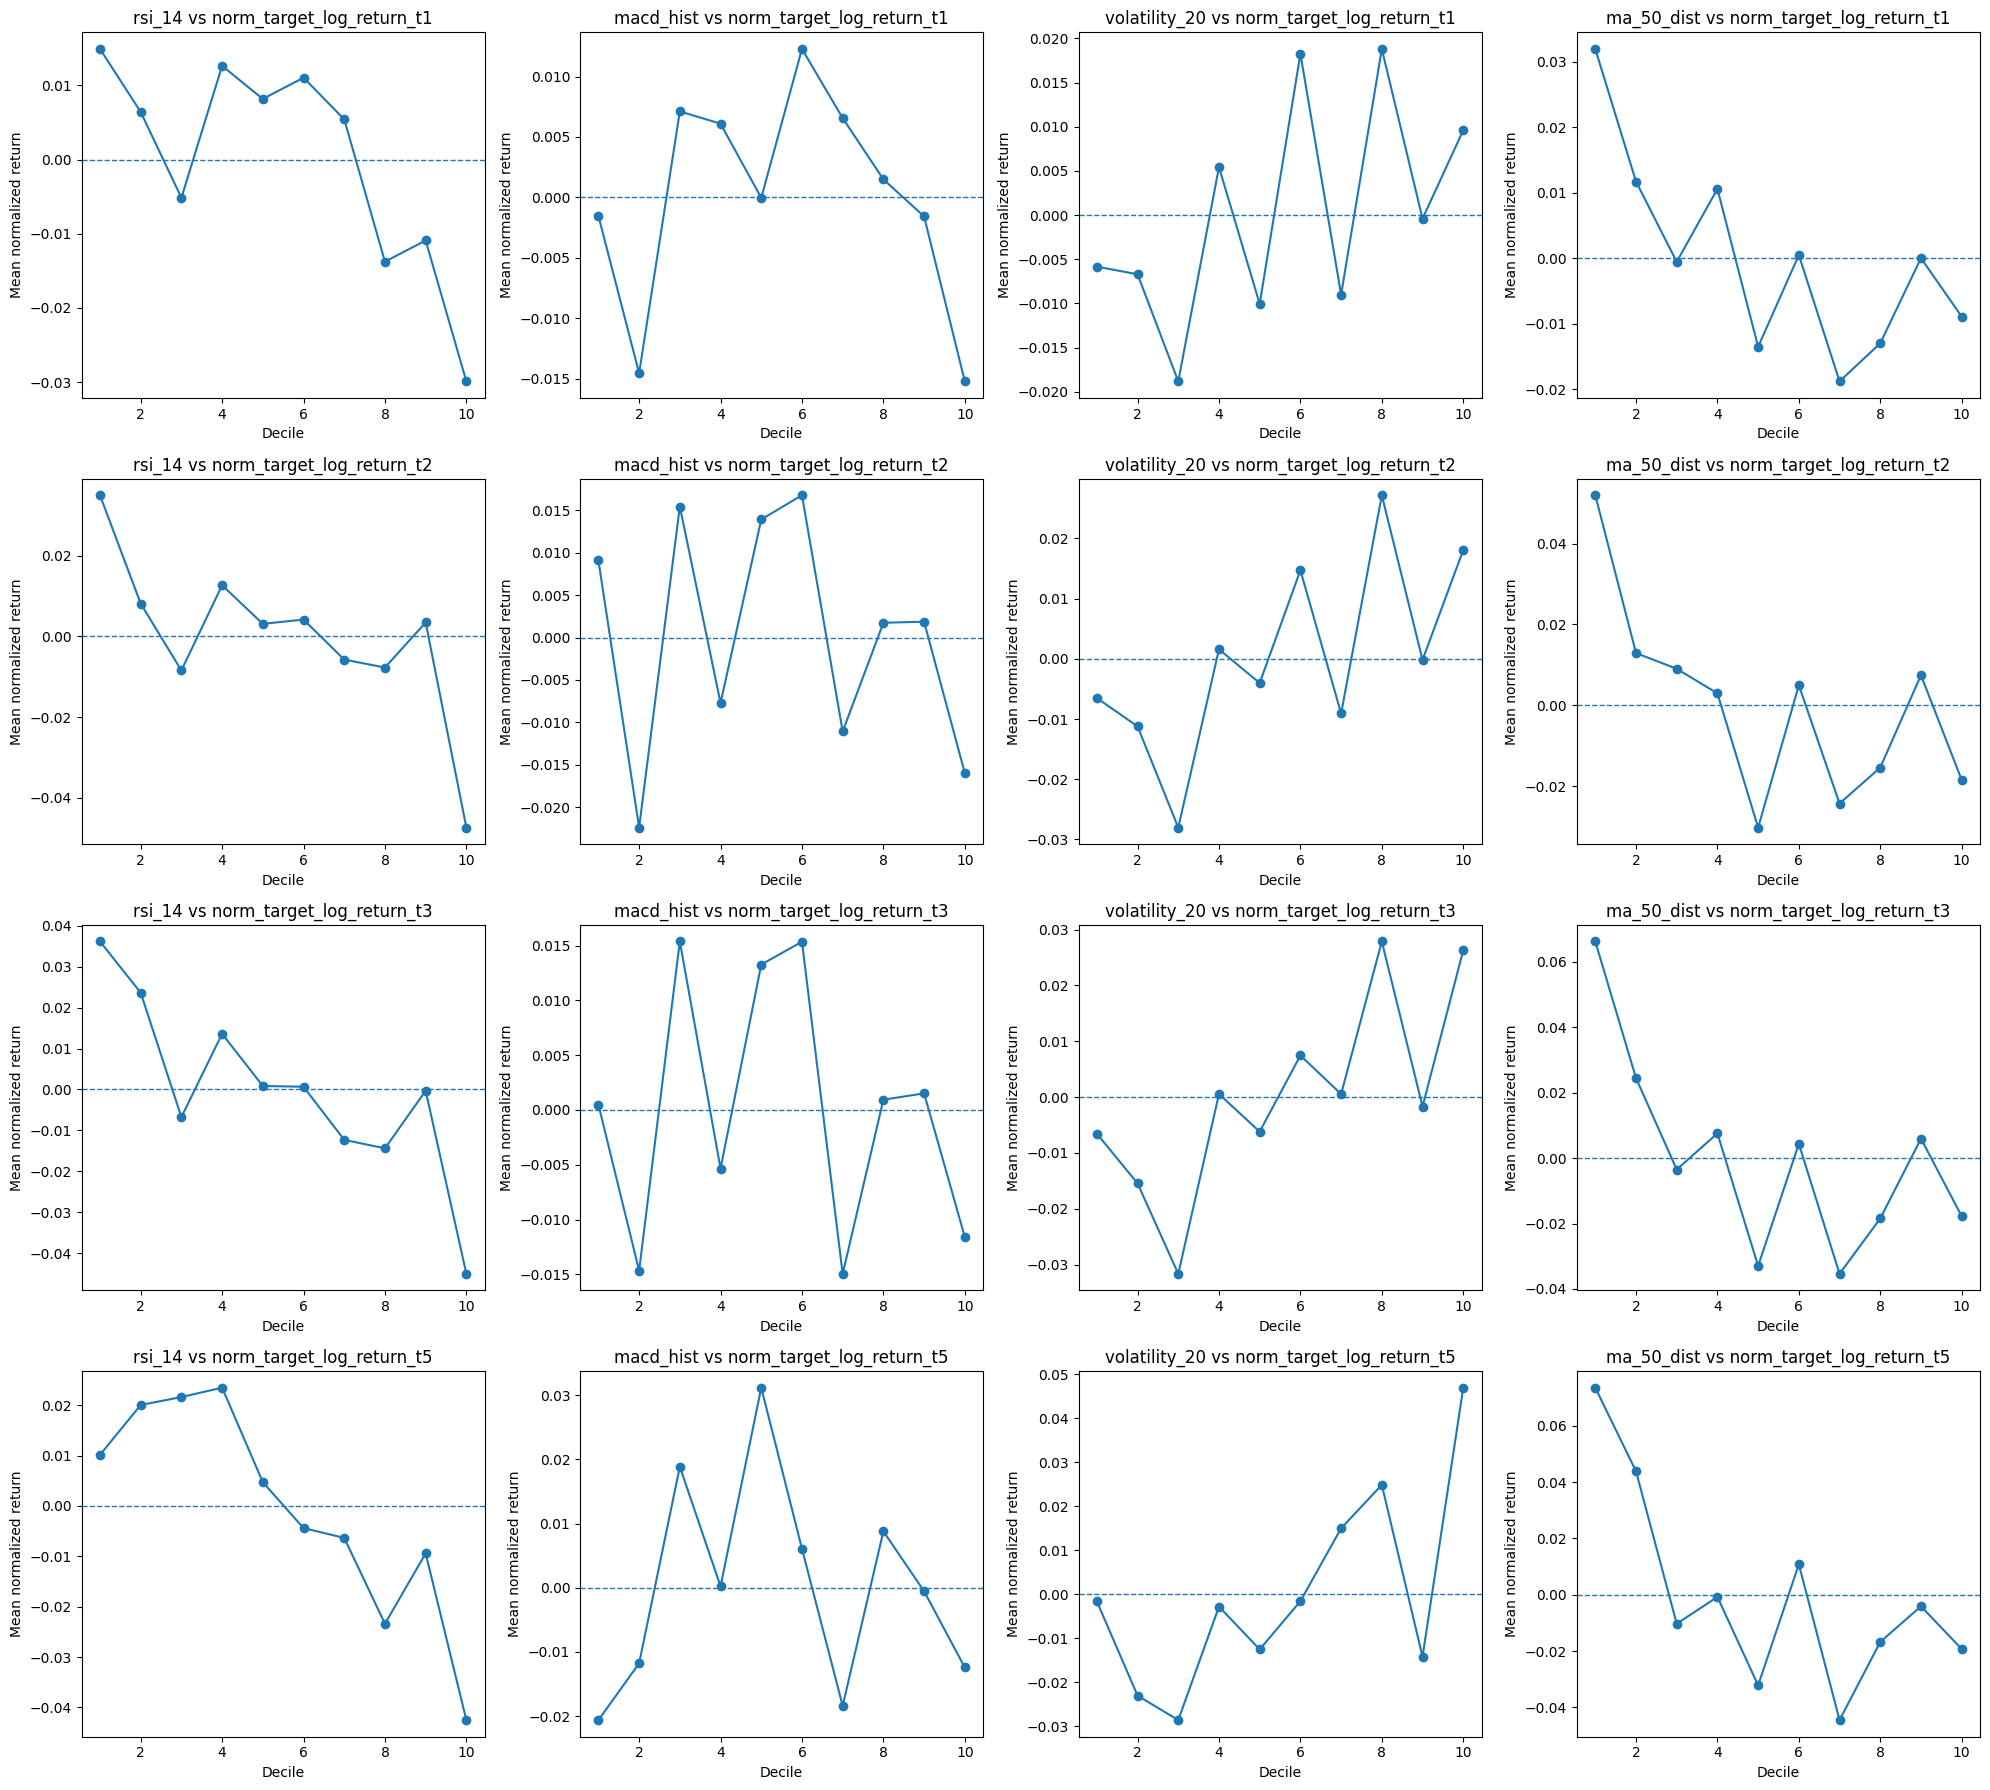

In [41]:
targets = [
    "norm_target_log_return_t1",
    "norm_target_log_return_t2",
    "norm_target_log_return_t3",
    "norm_target_log_return_t5"
]
indicators = ['rsi_14', 'macd_hist', 'volatility_20', 'ma_50_dist']

fig, axes = plt.subplots(4, 4, figsize=(20, 18))

for row, target in enumerate(targets):
    for col, indicator in enumerate(indicators):
        temp = price_return_multiday_df[[indicator, target]].dropna().copy()
        temp = temp[temp[indicator] != 0]
        temp['bin'] = pd.qcut(temp[indicator], q=10, duplicates='drop')
        grouped = temp.groupby('bin', observed=False)[target].mean()

        axes[row, col].plot(range(1, len(grouped) + 1), grouped.values, marker='o')
        axes[row, col].axhline(0, linestyle='--', linewidth=1)
        axes[row, col].set_title(f'{indicator} vs {target}')
        axes[row, col].set_xlabel('Decile')
        axes[row, col].set_ylabel('Mean normalized return')

plt.tight_layout()
plt.show()

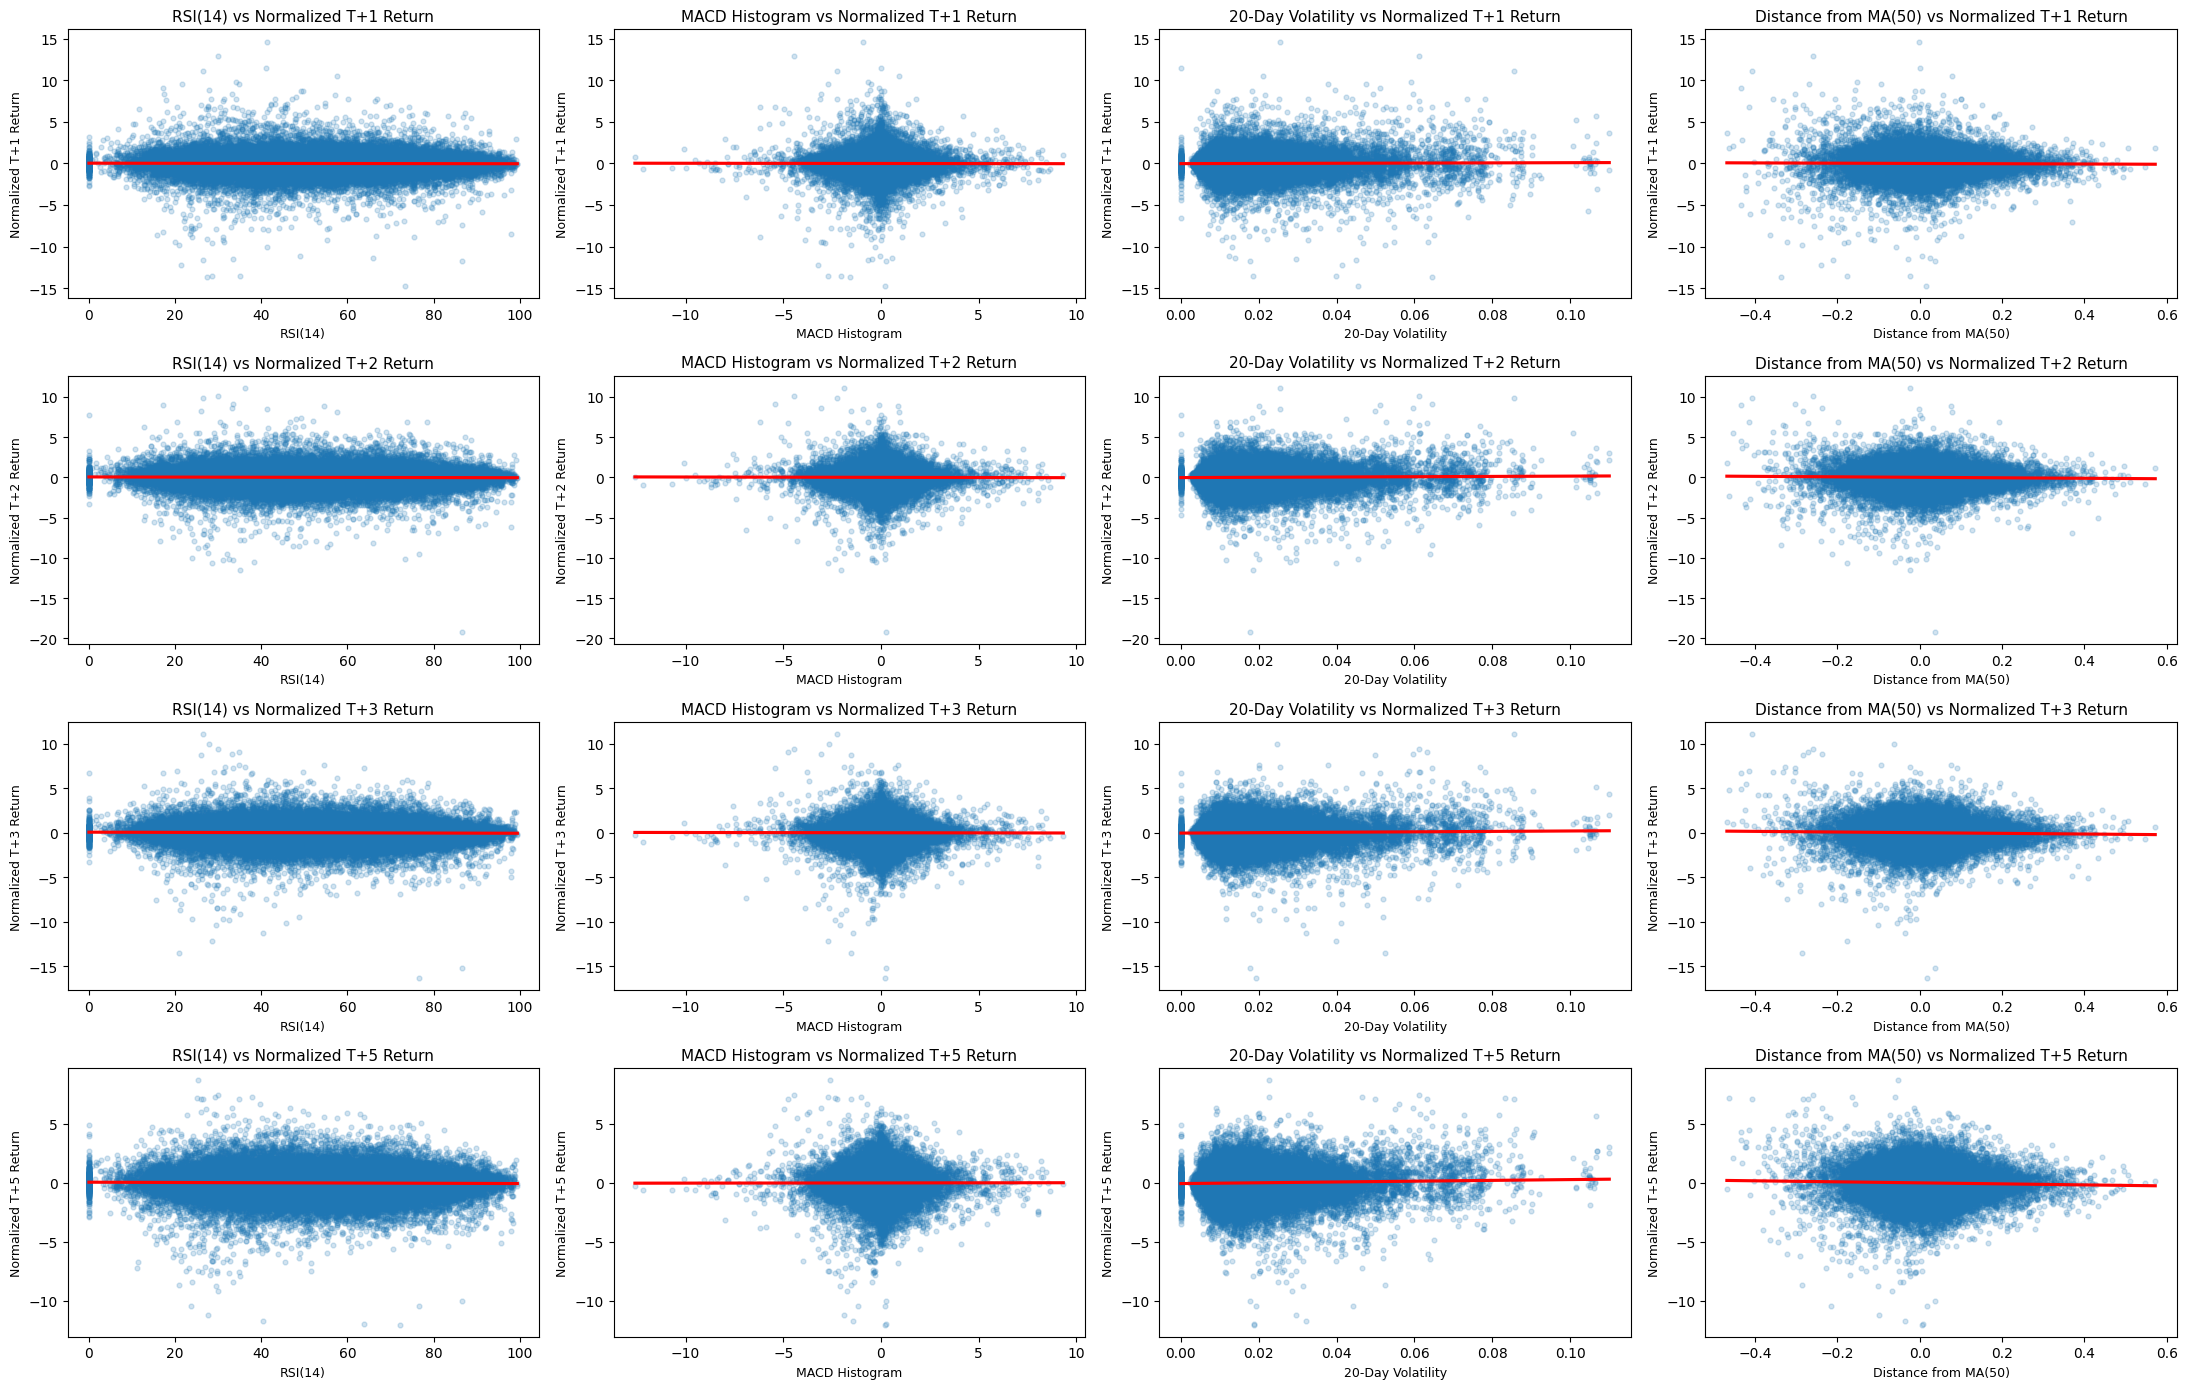

In [35]:
indicator_titles = {
    'rsi_14': 'RSI(14)',
    'macd_hist': 'MACD Histogram',
    'volatility_20': '20-Day Volatility',
    'ma_50_dist': 'Distance from MA(50)'
}

target_titles = {
    'norm_target_log_return_t1': 'Normalized T+1 Return',
    'norm_target_log_return_t2': 'Normalized T+2 Return',
    'norm_target_log_return_t3': 'Normalized T+3 Return',
    'norm_target_log_return_t5': 'Normalized T+5 Return'
}

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 14))

for row, target in enumerate(targets):
    for col, indicator in enumerate(indicators):
        ax = axes[row, col]

        sns.regplot(
            x=indicator,
            y=target,
            data=price_return_multiday_df,
            ax=ax,
            scatter_kws={'alpha': 0.2, 's': 12},
            line_kws={'color': 'red'},
            lowess=False
        )

        ax.set_title(f"{indicator_titles[indicator]} vs {target_titles[target]}", fontsize=11)
        ax.set_xlabel(indicator_titles[indicator], fontsize=9)
        ax.set_ylabel(target_titles[target], fontsize=9)

plt.tight_layout()
plt.show()

**Outcome** - The results show a different pattern compared to raw returns, particularly at the T+1 horizon.

Now across all horizons (T+1, T+2, T+3, T+5):

- **RSI (rsi_14):**  
  Statistically significant with negative correlation → consistent with mean-reversion behavior

- **Volatility (volatility_20):**  
  Statistically significant with positive correlation → associated with larger relative return deviations

- **MA Distance (ma_50_dist):**  
  Statistically significant with negative correlation → supports mean-reversion dynamics

- **MACD Histogram (macd_hist):**  
  Not significant across all horizons

- After normalization, two more indicators become statistically significant **even at the T+1 horizon**, in contrast to the raw return results  
- This indicates that predictive structure exists at the **within-asset level**, but is obscured in raw returns by cross-sectional differences in volatility and scale  
- The persistence of significance across T+2, T+3, and T+5 further supports the presence of **stable, delayed relationships**

However:
- Correlation magnitudes remain small, indicating **possible weak economic significance** despite strong statistical evidence  

**Conclusion**

Normalization of log returns reveals previously hidden structure in the data:

- Technical indicators do not reliably predict **absolute returns across assets**  
- However, they do exhibit statistically significant relationships with **relative (within-asset) return deviations**  

This suggests that the predictive signal is primarily **cross-sectionally normalized rather than absolute**, and persists across multiple time horizons. These findings provide stronger evidence of systematic patterns, but further analysis is required to determine whether they translate into economically meaningful trading performance.

**Multivariate Regression Analysis with Normalized Returns**

To further test the robustness of the detected relationships, a multivariate regression model is estimated using normalized future returns at horizons T+1, T+2, T+3, and T+5 as well as interaction terms designed to capture nonlinear and regime-dependent effects.

The null hypothesis is defined as:

**H₀ (Null Hypothesis):**  
None of the indicators or their interaction terms have explanatory power for normalized future returns.

**H₁ (Alternative Hypothesis):**  
At least one indicator or interaction term has statistically significant explanatory power.

The objective is to determine whether the predictive relationships observed in the univariate normalized-return analysis remain present when the indicators are considered jointly in a multivariate framework.

Statistical significance is evaluated at **$\alpha = 0.01$**.

In [25]:
targets = ["norm_target_log_return_t1", "norm_target_log_return_t2", "norm_target_log_return_t3", "norm_target_log_return_t5"]
for target in targets:
    multivariate_model = sig_utils.run_multivariate_test(price_return_multiday_df, target)
    print(multivariate_model.summary())

                                OLS Regression Results                               
Dep. Variable:     norm_target_log_return_t1   R-squared:                       0.000
Model:                                   OLS   Adj. R-squared:                  0.000
Method:                        Least Squares   F-statistic:                     3.341
Date:                       Wed, 15 Apr 2026   Prob (F-statistic):           0.000428
Time:                               07:53:17   Log-Likelihood:            -1.0669e+05
No. Observations:                      75210   AIC:                         2.134e+05
Df Residuals:                          75200   BIC:                         2.135e+05
Df Model:                                  9                                         
Covariance Type:                   nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

**Outcome** - The regression results confirm that the relationships identified in the normalized univariate analysis persist in a multivariate setting and become stronger at longer horizons:

- The overall model is **statistically significant at all horizons** (T+1 to T+5)
- However, explanatory power remains very limited:
  - **R² ≈ 0.000 at T+1**
  - rising gradually to **R² ≈ 0.004 at T+5**

At the strict significance level of **$\alpha = 0.01$**:

- **T+1:**  
  No individual indicator or interaction term is significant, despite the model being significant overall

- **T+2:**  
  - **RSI** becomes significant with a negative coefficient  
  - **RSI × Volatility** becomes significant with a positive coefficient  
  - **Volatility × MA Distance** is strongly significant and negative  

- **T+3:**  
  - **RSI** remains significant and negative  
  - **Volatility** becomes significant and negative  
  - **RSI × Volatility** remains strongly significant  
  - **Volatility × MA Distance** remains strongly significant  

- **T+5:**  
  - **RSI** remains strongly significant and negative  
  - **Volatility** remains strongly significant and negative  
  - **RSI × Volatility** strengthens further  
  - **Volatility × MA Distance** remains highly significant  
  - MACD-related effects remain weak or inconsistent


These results suggest that:

- Normalization does not remove the previously observed structure  
- Instead, it confirms that the predictive relationships are **within-asset and interaction-driven**
- The signal becomes clearer as the return horizon extends from T+1 to T+5
- The most stable and important effects involve:
  - **RSI**
  - **Volatility**
  - **their interaction**
  - and the interaction between **Volatility and MA Distance**

At the same time:
- the explanatory power of the model remains extremely small  
- this indicates that the detected structure is **statistically real but could be economically weak**

**Conclusion**

The normalized multivariate regressions reinforce the main conclusion of the analysis:

- Technical indicators do not provide meaningful explanatory power for immediate next-day normalized returns  
- However, weak but statistically significant structure emerges over longer horizons  
- This structure is primarily **conditional**, driven by interaction effects rather than simple additive relationships

Overall, the results support the presence of delayed, regime-dependent patterns in returns, while also showing that their practical effect size remains limited.

#### 8. Test signals on extended horizons

To evaluate whether the previously identified relationships translate into actionable signals, the categorical indicators are tested against normalized future returns across multiple horizons (T+1, T+2, T+3, T+5).

Two complementary approaches are used:
- **T-test:** compares mean returns following Buy signals versus Neutral periods  
- **ANOVA:** tests whether returns differ across all signal states (-1, 0, +1)

The null hypothesis is:
**H₀:**  
The signal has no effect on future normalized returns.

**H₁:**  
The signal is associated with differences in future normalized returns. All tests are evaluated at a strict significance level of **$\alpha = 0.01$**. The objective is to determine whether discretized signals retain predictive power after normalization and across multiple time horizons.

In [26]:
targets = ["norm_target_log_return_t1", "norm_target_log_return_t2", "norm_target_log_return_t3", "norm_target_log_return_t5"]
for target in targets:
    print(f"\n{'='*60}")
    print(f" T-Test Signal Performance for {target}")
    print(f"{'='*60}")

    signal_alpha = sig_utils.verify_signal_performance(price_return_multiday_df, target)
    print(signal_alpha)
    print("\n")


 T-Test Signal Performance for norm_target_log_return_t1
        Signal  Buy_Mean_Return  Neutral_Mean_Return  T_Statistic   P_Value  \
0      sig_rsi         0.012476             0.003230     0.734085  0.462900   
1     sig_macd         0.017523            -0.000683     0.976302  0.328918   
2      sig_vol        -0.008406            -0.005400    -0.394462  0.693242   
3  sig_ma_dist         0.014586             0.001269     0.766859  0.443168   

   Significant_01  
0           False  
1           False  
2           False  
3           False  



 T-Test Signal Performance for norm_target_log_return_t2
        Signal  Buy_Mean_Return  Neutral_Mean_Return  T_Statistic   P_Value  \
0      sig_rsi         0.030653             0.001672     2.322033  0.020234   
1     sig_macd        -0.001115             0.000474    -0.085334  0.931996   
2      sig_vol        -0.011843            -0.008452    -0.430240  0.667023   
3  sig_ma_dist         0.046101             0.000124     2.655231  0.0

In [27]:
targets = ["norm_target_log_return_t1", "norm_target_log_return_t2", "norm_target_log_return_t3", "norm_target_log_return_t5"]
indicators = ['sig_rsi', 'sig_macd', 'sig_vol', 'sig_ma_dist']

for target in targets:
    print(f"\n{'='*60}")
    print(f" ANOVA Results for {target}")
    print(f"{'='*60}")

    anova_df = sig_utils.run_multivariate_anova(price_return_multiday_df, target, indicators)
    print(anova_df)
    print("\n")


 ANOVA Results for norm_target_log_return_t1
     Indicator  F_Statistic   P_Value  Reject_H0_01
0      sig_rsi     3.526779  0.029404         False
1     sig_macd     0.484540  0.615982         False
2      sig_vol     4.683816  0.009246          True
3  sig_ma_dist     1.779985  0.168648         False



 ANOVA Results for norm_target_log_return_t2
     Indicator  F_Statistic   P_Value  Reject_H0_01
0      sig_rsi     7.425872  0.000596          True
1     sig_macd     0.153050  0.858087         False
2      sig_vol    10.438694  0.000029          True
3  sig_ma_dist     6.002352  0.002474          True



 ANOVA Results for norm_target_log_return_t3
     Indicator  F_Statistic       P_Value  Reject_H0_01
0      sig_rsi     7.821693  4.012687e-04          True
1     sig_macd     0.127251  8.805127e-01         False
2      sig_vol    14.902901  3.380915e-07          True
3  sig_ma_dist    13.575206  1.274756e-06          True



 ANOVA Results for norm_target_log_return_t5
     Indic

**Outcome** - The results reveal a clear divergence between short-term and multi-day horizons.

- **T+1:**  
  - No signals are statistically significant under the t-test  
  - Only volatility shows significance under ANOVA  
  → No robust signal at the immediate horizon

- **T+2 to T+5:**  
  - **RSI, Volatility, and MA Distance** become statistically significant under ANOVA  
  - **MA Distance** consistently shows strong significance in t-tests  
  - **MACD** remains insignificant across all tests and horizons 
- Signal effectiveness **emerges only over longer horizons**, consistent with earlier findings  
- **MA Distance** shows the strongest and most consistent performance  
- **RSI and Volatility** exhibit significance primarily at the group level (ANOVA), suggesting broader distributional effects rather than simple mean differences  
- The persistence of results under normalization confirms that the signals operate at the **within-asset level**, not due to cross-sectional volatility bias  

**Conclusion**

The categorical signal analysis confirms that:
- No meaningful signal exists at T+1  
- Statistically significant signal structure emerges at T+2 and beyond  
- The predictive effects are **weak, delayed, and signal-specific**, with MA Distance being the most consistent contributor  

These results reinforce the conclusion that technical signals do not provide short-term predictive power but may capture **gradual adjustment dynamics** over multi-day horizons.

**Integrated Categorical Signal Testing Framework** - The objective of the following three tests is to evaluate whether discretized technical indicators contain **predictive information about future return direction and distribution**, after controlling for volatility effects through normalization for T+1 through T+5:

- **Directional Chi-Squared (Aligned):**  
  Tests whether Buy/Sell signals correctly predict the direction of future returns
- **Interaction ANOVA:**  
  Tests whether signal states and their interactions influence the distribution (magnitude) of returns
- **Confluence Chi-Squared:**  
  Tests whether agreement between multiple signals (additive aggregation) improves predictive performance

The null hypothesis across all tests is:

**H₀:**  Categorical signals, individually or in combination, have no relationship with future normalized returns.

**H₁:**  Categorical signals contain predictive information, either individually, through interactions, or via aggregation. 

The goal is to determine whether at **$\alpha = 0.01$**:
- Signals provide **directional predictive power**
- Predictive structure is **additive (confluence)** or **conditional (interaction-based)**
- Signal effectiveness improves across **longer time horizons (T+2 to T+5)**

In [28]:
targets = [
    "norm_target_log_return_t1",
    "norm_target_log_return_t2",
    "norm_target_log_return_t3",
    "norm_target_log_return_t5"
]

for target in targets:
    chi2_df = sig_utils.run_signal_chi2_aligned(price_return_multiday_df, target)

    print(f"\n{'='*80}")
    print(f" Directional Chi-Squared Results for: {target}")
    print(f"{'='*80}")
    print(chi2_df.to_string(index=False))
    print("\n")


 Directional Chi-Squared Results for: norm_target_log_return_t1
  Indicator  Chi2_Stat  P_Value  Significant_01  Observations
    sig_rsi  11.516107 0.000690            True         21139
   sig_macd   0.169785 0.680303           False          6034
    sig_vol   2.210881 0.137040           False         37642
sig_ma_dist   5.337513 0.020871           False         10256



 Directional Chi-Squared Results for: norm_target_log_return_t2
  Indicator  Chi2_Stat  P_Value  Significant_01  Observations
    sig_rsi  13.012710 0.000309            True         21139
   sig_macd   0.016521 0.897726           False          6034
    sig_vol   8.971875 0.002742            True         37642
sig_ma_dist   6.650876 0.009911            True         10256



 Directional Chi-Squared Results for: norm_target_log_return_t3
  Indicator    Chi2_Stat  P_Value  Significant_01  Observations
    sig_rsi 9.748099e+00 0.001795            True         21139
   sig_macd 5.899198e-09 0.999939           False    

In [29]:
targets = [
    "norm_target_log_return_t1",
    "norm_target_log_return_t2",
    "norm_target_log_return_t3",
    "norm_target_log_return_t5"
]

for target in targets:
    formula = f"""
    {target} ~ 
    C(sig_rsi) + 
    C(sig_vol) + 
    C(sig_ma_dist) + 
    C(sig_rsi):C(sig_vol) + 
    C(sig_vol):C(sig_ma_dist)
    """

    model = ols(formula, data=price_return_multiday_df).fit()
    aov_table = sm.stats.anova_lm(model, typ=2)

    print(f"\n{'='*80}")
    print(f" Interaction ANOVA Results for: {target}")
    print(f"{'='*80}")
    print(aov_table.to_string())
    print("\n")


 Interaction ANOVA Results for: norm_target_log_return_t1
                                 sum_sq       df         F    PR(>F)
C(sig_rsi)                     3.227552      2.0  1.614879  0.198922
C(sig_vol)                     8.457018      2.0  4.231398  0.014536
C(sig_ma_dist)                 0.314820      2.0  0.157518  0.854262
C(sig_rsi):C(sig_vol)         11.782726      4.0  2.947694  0.018983
C(sig_vol):C(sig_ma_dist)      4.455414      4.0  1.114615  0.347510
Residual                   75143.653844  75195.0       NaN       NaN



 Interaction ANOVA Results for: norm_target_log_return_t2
                                 sum_sq       df         F    PR(>F)
C(sig_rsi)                     5.464272      2.0  2.734772  0.064915
C(sig_vol)                    18.145480      2.0  9.081495  0.000114
C(sig_ma_dist)                 2.691160      2.0  1.346878  0.260057
C(sig_rsi):C(sig_vol)         10.001556      4.0  2.502802  0.040248
C(sig_vol):C(sig_ma_dist)      4.687518      4.0  1.

In [30]:
targets = [
    "norm_target_log_return_t1",
    "norm_target_log_return_t2",
    "norm_target_log_return_t3",
    "norm_target_log_return_t5"
]

for target in targets:
    price_return_multiday_df['outcome_win'] = (price_return_multiday_df[target] > 0).astype(int)

    contingency_conf = pd.crosstab(
        price_return_multiday_df['confluence_score'], 
        price_return_multiday_df['outcome_win']
    )

    chi2_c, p_c, dof_c, ex_c = st.chi2_contingency(contingency_conf)

    print(f"\n{'='*70}")
    print(f" Confluence Chi-Squared Results for: {target}")
    print(f"{'='*70}")
    print(f"P-Value: {p_c:.4e}")
    print(f"Significant at α=0.01? {'YES' if p_c < 0.01 else 'NO'}")
    print("\n")


 Confluence Chi-Squared Results for: norm_target_log_return_t1
P-Value: 1.2053e-02
Significant at α=0.01? NO



 Confluence Chi-Squared Results for: norm_target_log_return_t2
P-Value: 3.5327e-03
Significant at α=0.01? YES



 Confluence Chi-Squared Results for: norm_target_log_return_t3
P-Value: 3.6784e-04
Significant at α=0.01? YES



 Confluence Chi-Squared Results for: norm_target_log_return_t5
P-Value: 8.1286e-04
Significant at α=0.01? YES




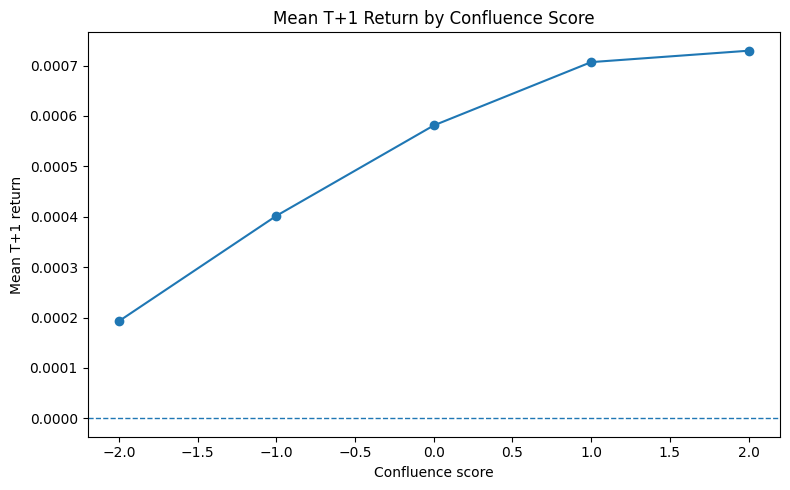

In [42]:
confluence_plot_df = final_signal_df[['confluence_score', 'target_log_return_t1']].dropna().copy()
grouped = confluence_plot_df.groupby('confluence_score')['target_log_return_t1'].mean()

plt.figure(figsize=(8, 5))
plt.plot(grouped.index, grouped.values, marker='o')
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('Mean T+1 Return by Confluence Score')
plt.xlabel('Confluence score')
plt.ylabel('Mean T+1 return')
plt.tight_layout()
plt.show()

**Outcome** - The results appear to reveal a pattern across all three testing approaches.

1. **Directional Predictability (Chi-Squared Aligned):**
   - At T+1: limited evidence of predictive power  
   - At T+2 and T+3: RSI, Volatility, and MA Distance become statistically significant  
   - At T+5: Volatility and MA Distance remain significant, RSI weakens  
   - MACD is consistently insignificant  

2. **Interaction Effects (ANOVA):**
   - Volatility is the most consistently significant variable across all horizons  
   - The **RSI × Volatility interaction** becomes increasingly significant as horizon increases  
   - MA Distance gains importance at longer horizons  
   - Interaction effects dominate over individual effects  

3. **Confluence (Additive Aggregation):**
   - Not significant at T+1  
   - Becomes significant at T+2, T+3, and T+5  
   - Indicates that signal agreement has some predictive value, but only at longer horizons  


- Predictive structure is **not present at the immediate (T+1) horizon**, but emerges consistently at **multi-day horizons**
- Signals exhibit **weak but stable directional predictive power** after normalization  
- The effectiveness of signals depends more on **interactions and context** than on standalone effects  
- Volatility acts as a **key conditioning variable**, influencing how other signals behave  
- Additive signal aggregation (confluence) becomes relevant only over longer holding periods  

**Conclusion**

These results lead to the following conclusions:

- **Short-term trading (T+1) based on these signals is not supported**
- Signals should be designed for **multi-day horizons (T+2 to T+5)**
- Signal construction should prioritize:
  - **Interaction-based logic** (e.g. RSI conditioned on volatility)
  - **Selective aggregation**, rather than naive summation
- Volatility should be treated as a **regime variable**, not just another signal component
- MACD should be excluded or deprioritized due to lack of empirical support  

The analysis demonstrates that technical signals do not operate as independent or purely additive predictors. Instead, they exhibit **weak, delayed, and regime-dependent predictive structure**, which becomes detectable only after normalization and over longer time horizons.

This supports a signal design approach based on **conditional relationships and multi-day holding periods**, rather than short-term directional prediction or simple indicator stacking.

#### 9. Create the Signal

Based on the empirical results from the statistical tests, I constructed the final trading signal using a **rule-based, interaction-aware approach**, rather than naive aggregation.

**Methodological Justification**

The signal design is informed by three key findings:

1. **Lack of Predictive Power at T+1, Emergence at T+2+**  
   The indicators do not exhibit consistent predictive power at the next-day horizon, but become statistically significant at multi-day horizons (T+2 to T+5). This implies that signal effects are **delayed rather than immediate**.

2. **Dominance of Interaction Effects over Individual Signals**  
   The Interaction ANOVA demonstrates that **RSI × Volatility** is consistently significant, while standalone indicators are weak or unstable. This indicates that signals are **context-dependent**, not independent drivers.

3. **Conditional Role of Volatility**  
   Volatility appears as the most consistent explanatory variable across tests. However, its effect is primarily **modulatory**, influencing the effectiveness of other indicators rather than acting as a standalone predictor.

4. **Weakness of Additive Confluence**  
   Simple summation of signals (confluence) does not produce reliable predictive power at short horizons and only becomes marginally relevant at longer horizons. This rejects a purely **additive signal framework**.

**Signal Construction Logic**

Given these findings, the final signal is constructed using:

- **RSI and MA Distance** as primary directional indicators  
- **Volatility as a conditioning variable (regime filter)**  
- **MACD excluded** due to lack of statistical support  

The signal follows a conditional structure:

- **Buy (+1):**  
  Low volatility regime AND at least one bullish directional signal (RSI or MA Distance)

- **Sell (-1):**  
  High volatility regime AND at least one bearish directional signal

- **Hold (0):**  
  All other cases

The final dataset contains, for each date-ticker observation:
- Open price  
- Close price  
- A single combined trading signal ∈ {−1, 0, +1}  

This output serves as the direct input for portfolio backtesting in the last notebook 1_4.

In [31]:
signal_export_df = price_return_multiday_df.copy()

signal_export_df['combined_signal'] = np.select(
    [
        (signal_export_df['sig_vol'] == 1) &
        ((signal_export_df['sig_rsi'] == 1) | (signal_export_df['sig_ma_dist'] == 1)),

        (signal_export_df['sig_vol'] == -1) &
        ((signal_export_df['sig_rsi'] == -1) | (signal_export_df['sig_ma_dist'] == -1))
    ],
    [1, -1],
    default=0
)

open_price_df = data_pipe.build_open_price_df(tickers, PROJECT_ROOT)
open_price_df = open_price_df.reset_index().melt(id_vars=['Date'], var_name='Ticker', value_name='open_price')
signal_export_df = signal_export_df.merge(open_price_df, how='left', on=['Date', 'Ticker'])
final_signal_export = signal_export_df[
    ['Date', 'Ticker', 'open_price', 'close_price', 'combined_signal']
].copy()
final_signal_export.to_csv(DATA_DIR / "final_signal_export.csv")
final_signal_export

,Date,Ticker,open_price,close_price,combined_signal
0,2016-04-01,AAPL,24.636544,24.684103,1
1,2016-04-04,AAPL,25.007968,24.910585,1
2,2016-04-05,AAPL,24.801878,25.166506,1
3,2016-04-06,AAPL,24.964938,24.869822,1
4,2016-04-07,AAPL,24.901522,25.130268,1
...,...,...,...,...,...
75205,2026-03-16,XOM,156.000000,156.119995,0
75206,2026-03-17,XOM,158.250000,157.229996,0
75207,2026-03-18,XOM,159.660004,158.809998,0
75208,2026-03-19,XOM,158.259995,157.589996,0


#### Conclusion

This notebook investigated whether commonly used technical indicators contain statistically significant predictive information about future stock returns. The analysis followed a structured pipeline: constructing continuous indicators from price data, transforming them into categorical trading signals, and evaluating their predictive power through a comprehensive suite of statistical tests.

##### Summary of Findings

The results consistently show that **individual technical indicators exhibit weak or negligible predictive power at the immediate (T+1) horizon**. Both correlation analysis and univariate hypothesis testing fail to reject the null hypothesis for most indicators, indicating that short-term price movements remain largely unpredictable using standalone signals.

However, the analysis reveals a more nuanced structure when extending the horizon and refining the methodology:

- At **multi-day horizons (T+2 to T+5)**, several indicators—particularly RSI, volatility, and MA distance—begin to exhibit **statistically significant relationships** with future returns.
- **Normalization of returns (per ticker)** strengthens these relationships, indicating that raw return dynamics are partially obscured by cross-sectional volatility differences.
- **Categorical signal testing** confirms that directional predictability is weak at T+1 but becomes more stable and statistically detectable over longer horizons.
- **Interaction effects**, especially between RSI and volatility, emerge as consistently significant. This demonstrates that indicator effectiveness is **conditional rather than independent**.
- In contrast, **additive signal aggregation (confluence)** provides limited explanatory power and only becomes marginally relevant at longer horizons.
- The MACD indicator shows **no consistent statistical support** across any test and is therefore excluded from the final signal design.

##### Interpretation

Taken together, the results suggest that technical indicators do not function as simple, standalone predictors of price direction. Instead, they exhibit:

- **Delayed predictive effects** (multi-day rather than next-day)
- **Weak but statistically detectable structure**
- **Dependence on market regime**, particularly volatility
- **Non-additive behavior**, where interactions dominate over simple aggregation

This implies that effective signal construction must move beyond naive stacking of indicators and instead incorporate **conditional logic based on empirical relationships**.

##### Implications for Signal Design

Based on these findings, the final trading signal constructed in this notebook reflects:

- Use of **RSI and MA Distance** as primary directional components  
- Treatment of **volatility as a conditioning variable (regime filter)**  
- Exclusion of **MACD** due to lack of statistical significance  
- Adoption of a **rule-based, interaction-aware framework**, rather than linear aggregation  

The resulting dataset provides a single combined trading signal per date and ticker, designed to be consistent with the observed statistical properties of the indicators.

##### Final Remarks

While the detected effects are statistically significant, they may remain **economically modest**, with their very low explanatory power (low R² values). This will probably reinforce one of the perspectives that financial markets are difficult to predict and that any exploitable structure is subtle and context-dependent.

##### Next Steps

The next stage of the project (Notebook 1_3) will extend the analysis by incorporating **textual data from EDGAR filings (8-K and 10-Q reports)**. This includes:

- Extraction and preprocessing of textual disclosures  
- Construction of sentiment scores using NLP techniques  
- Hypothesis testing of sentiment-based signals  

The objective is to evaluate whether **fundamental information derived from text can enhance or complement the technical signal framework**, and if so potentially to improve predictive performance if combined.